#  Small-scale snow cover variability and its effect on soil surface temperatures in West Greenland

Sofia Rosa Bauriedl

Models I implemented for the paper

In [183]:
# system
import os
import os.path as path

# data
import numpy as np
import pandas as pd

# stats / inference
import pymc as pm
import bambi as bmb
from bambi.priors import Prior
import arviz as az
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import arviz as az

# plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

## Data

In [184]:
# Load the main dataframe
# change to your file path (I saved the files on my local desktop, because this accelarated loading them and working on the notebook offline)

#path = r"\\dmawi.de\potsdam\data\sparc\personal_accounts\02_Master\2025_Sofia_Bauriedl\Paper\01_data\TOMST_Paper.csv"

#df = pd.read_csv(path, sep=";")
df = pd.read_csv("C:/Users/sobaur001/Downloads/TOMST_Paper.csv", sep=";")
model_vars = ['snow_depth', 'bulk_density', 'T_snow', 'T_surface', 'topography', 'vegetation', 'TMS_ID','T_air_1', 'T_soil', 'elevation', 'aspect', 'slope']  # example
df = df.dropna(subset=model_vars).copy()


In [185]:
df

,tomst_id,sr_nr,TMS_ID,Transect,Plot,Lat,Lon,vegetation,topography,slope,...,aspect,snow_depth,bulk_density,T_snow,T_surface,T_soil,T_air_1,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,6,94231022.0,A,3.0,1.0,69.278881,-53.479375,dry tundra,footslope,2.66,...,6.63,0.81,0.307,-4.83,-3.98,-3.93,-7.09,NaN,NaN,NaN
1,7,94231023.0,B,3.0,2.0,69.278717,-53.477737,dry shrub,footslope,4.90,...,269.73,0.59,0.297,-3.84,-2.99,-2.95,-7.09,NaN,NaN,NaN
2,8,94231024.0,C,3.0,2.0,69.278723,-53.477548,moist tundra,plain,0.47,...,261.64,0.74,0.286,-4.28,-3.45,-3.31,-7.09,NaN,NaN,NaN
3,10,94231026.0,D,3.0,3.0,69.278574,-53.474810,moist tundra,hillslope,17.38,...,283.70,0.96,0.343,-0.61,-0.34,-0.60,-7.09,NaN,NaN,NaN
4,15,94231031.0,E,3.0,4.0,69.278654,-53.474111,dry tundra,footslope,4.25,...,198.99,0.36,0.272,-4.49,-5.45,-5.90,-7.09,NaN,NaN,NaN
5,16,94231032.0,H,1.0,1.0,69.267720,-53.466919,moist tundra,footslope,3.27,...,320.75,0.57,0.289,-2.15,-1.27,-1.16,-7.09,NaN,NaN,NaN
6,19,94231035.0,I,1.0,2.0,69.268028,-53.466093,moist tundra,footslope,2.06,...,285.21,0.68,0.295,-4.50,-3.86,-3.75,-7.09,NaN,NaN,NaN
7,20,94231036.0,J,1.0,2.0,69.267811,-53.466177,moist shrub,plain,0.68,...,146.00,0.48,0.289,-4.81,-4.46,-4.41,-7.09,NaN,NaN,NaN
8,23,94231039.0,K,1.0,3.0,69.268148,-53.464995,dry shrub,footslope,2.75,...,313.23,0.59,0.286,-3.64,-2.51,-2.00,-7.09,NaN,NaN,NaN
9,25,94231041.0,L,1.0,4.0,69.268748,-53.462484,dry tundra,footslope,2.60,...,278.80,0.56,0.299,-4.66,-3.83,-3.75,-7.09,NaN,NaN,NaN


In [3]:
# --- Ensure numeric ---
df["slope"] = pd.to_numeric(df["slope"], errors="coerce")
df["snow_depth"] = pd.to_numeric(df["snow_depth"], errors="coerce")
df["bulk_density"] = pd.to_numeric(df["bulk_density"], errors="coerce")
df["elevation"] = pd.to_numeric(df["elevation"], errors="coerce")
df["T_air_1"] = pd.to_numeric(df["T_air_1"], errors="coerce")

# 1) Snow depth: scale per 10 cm 
df["snow_10cm"] = df["snow_depth"] / 0.1

# 2) Bulk density: scale per 10 g/cm³ and center
df["density_01"] = df["bulk_density"] / 0.1

# 3) Elevation: convert to meters, scale per 10 m, center
df["elevation_m"] = df["elevation"]  # already in meters
df["elev_10m"] = df["elevation_m"] / 10

# 4) Slope: keep per 1 degree 

# 5) Aspect: convert to sin/cos (already bounded -1 to 1)
df["aspect_rad"] = np.radians(df["aspect"])
df["aspect_sin"] = np.sin(df["aspect_rad"])
df["aspect_cos"] = np.cos(df["aspect_rad"])

## Define functions

In [4]:
def run_model(model, draws=3000, tune=3000, prior_draws=1000):
    """
    Runs prior predictive, posterior sampling,
    and posterior predictive sampling for a PyMC model.
    
    Returns:
        prior, idata
    """
    
    with model:
        
        # Prior predictive
        prior = pm.sample_prior_predictive(prior_draws)
        
        # Posterior sampling
        idata = pm.sample(
            draws,
            tune=tune,
            target_accept=0.9,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True}
        )
        
        # Posterior predictive
        idata = pm.sample_posterior_predictive(
            idata,
            extend_inferencedata=True
        )
    
    return prior, idata


In [5]:
def plot_all_prior_coefficients(prior, group="prior"):
    
    vars_in_model = list(prior[group].data_vars)
    
    vars_to_plot = [
        v for v in vars_in_model
        if v.startswith("beta_") or v.startswith("sigma_")
    ]
    
    az.plot_density(
        prior,
        group=group,
        var_names=vars_to_plot
    )

In [6]:
def summarize_all_prior_coefficients(prior, group="prior", round_to=2):
    
    vars_in_model = list(prior[group].data_vars)
    

    vars_to_summarize = [
        v for v in vars_in_model
        if (
            v == "alpha"
            or v == "sigma"
            or v.startswith("beta_")
            or v.startswith("sigma_")
        )
    ]
    
    if len(vars_to_summarize) == 0:
        print("No matching prior coefficients found.")
        return None
    
    summary = az.summary(
        prior,
        group=group,
        var_names=vars_to_summarize,
        round_to=round_to
    )
    
    return summary


In [7]:
def summarize_all_posterior_coefficients(idata, group="posterior", round_to=2):
    
    vars_in_model = list(idata[group].data_vars)
    
    vars_to_summarize = [
        v for v in vars_in_model
        if (
            v == "alpha"
            or v == "sigma"
            or v.startswith("beta_")
            or v.startswith("sigma_")
        )
    ]
    
    if len(vars_to_summarize) == 0:
        print("No matching variables found.")
        return None
    
    summary = az.summary(
        idata,
        var_names=vars_to_summarize,
        group=group,
        round_to=round_to
    )
    
    return summary


In [8]:
def plot_all_posterior_coefficients(idata, group="posterior"):
    
    vars_in_model = list(idata[group].data_vars)
    
    vars_to_plot = [
        v for v in vars_in_model
        if (
            v == "alpha"
            or v == "sigma"
            or v.startswith("beta_")
        )
    ]
    
    if len(vars_to_plot) == 0:
        print("No matching posterior coefficients found.")
        return
    
    az.plot_posterior(
        idata,
        group=group,
        var_names=vars_to_plot
    )

In [9]:
def plot_residual_qq(idata, y_observed, var_name="T_surface"):
    """
    Compute posterior mean predictions and plot QQ plot of residuals.
    
    idata: InferenceData with posterior_predictive
    y_observed: observed response array
    var_name: name of predicted variable
    """
    
    # Posterior mean predictions
    y_pred = idata.posterior_predictive[var_name].mean(
        dim=("chain", "draw")
    ).values
    
    residuals = y_observed - y_pred
    
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot of Residuals ({var_name})")
    plt.show()
    
    return residuals

In [10]:
def compute_bayesian_r2(idata, y_observed, var_name="T_surface"):
    """
    Compute Bayesian R² and return as DataFrame.
    """
    
    r2 = az.r2_score(
        y_observed,
        idata.posterior_predictive[var_name]
    )
    
    r2_mean = float(r2["r2"])
    r2_sd   = float(r2["r2_std"])
    
    r2_table = pd.DataFrame({
        "R2_mean": [r2_mean],
        "R2_sd": [r2_sd]
    })
    
    return r2_table

In [11]:
def compute_bayesian_r2(idata, y_observed, var_name="T_surface"):
    """
    Compute Bayesian R² using posterior predictive samples.
    Returns DataFrame with mean and SD.
    """

    # Stack chains and draws
    y_pred = idata.posterior_predictive[var_name]
    y_pred = y_pred.stack(sample=("chain", "draw")).values.T  # shape (samples, obs)

    r2 = az.r2_score(y_observed, y_pred)

    r2_table = pd.DataFrame({
        "R2_mean": [float(r2["r2"])],
        "R2_sd": [float(r2["r2_std"])]
    })

    return r2_table


In [12]:
def compute_loo(idata):
    """
    Compute LOO and return ArviZ LOO object.
    """
    loo = az.loo(idata)
    return loo


In [13]:
def plot_prior_predictions(prior, var="T_surface"):
    """
    Plot prior predictive distributions for each observation
    along with the actual observed data.
    
    prior: ArviZ InferenceData object returned by pm.sample_prior_predictive()
    var: the name of the predicted variable
    """
    
    # Prior predictive samples
    pred = prior.prior_predictive[var]
    
    # Observed data if available
    obs = prior.observed_data[var].values if "observed_data" in prior.groups() else None
    
    # Convert xarray to DataFrame for seaborn
    pred_df = pred.to_dataframe().reset_index()
    
    fig, ax = plt.subplots(figsize=(8,5))
    
    # Boxplot of prior predictive distributions
    sns.boxplot(
        data=pred_df,
        x=f"{var}_dim_0",  # x-axis = observation index
        y=var,
        ax=ax
    )
    
    # Overlay observed data if available
    if obs is not None:
        ax.scatter(
            range(len(obs)),
            obs,
            color="red",
            marker="*",
            zorder=10,
            label="Observed"
        )
    
    ax.set_title("Prior Predictive Distribution")
    ax.set_xlabel("Observation index")
    ax.set_ylabel(var)
    if obs is not None:
        ax.legend()
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    return fig, ax


In [14]:
def plot_predictions(idata, var="T_surface"):
    
    pred = idata.posterior_predictive[var]
    obs = idata.observed_data[var]
    
    pred_df = pred.to_dataframe().reset_index()
    
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.boxplot(
        data=pred_df,
        x="T_surface_dim_0",
        y=var,
        ax=ax
    )
    
    ax.scatter(
        range(len(obs)),
        obs,
        color="red",
        marker="*",
        zorder=10,
        label="Observed"
    )
    
    ax.set_title("Posterior Predictive Distribution")
    ax.set_xlabel("Observation index")
    ax.set_ylabel("T_surface")
    ax.legend()
    
    return fig, ax


In [15]:
def qqplot(idata, var="T_surface"):
    
    pred = idata.posterior_predictive[var]
    obs = idata.observed_data[var]
    
    qhi = pred.quantile(0.97, dim=["chain","draw"])
    qlo = pred.quantile(0.03, dim=["chain","draw"])
    qmid = pred.median(dim=["chain","draw"])
    
    plt.figure(figsize=(6,6))
    plt.axline((0,0), slope=1, c='black')
    
    plt.errorbar(
        obs,
        qmid,
        yerr=np.stack([qmid - qlo, qhi - qmid]),
        fmt="o"
    )
    
    lo = float(min(qlo.min(), obs.min()))
    hi = float(max(qhi.max(), obs.max()))
    
    plt.xlim((lo,hi))
    plt.ylim((lo,hi))
    
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title("QQ Plot")
    plt.show()


# Bayesian Models (MCMC)
- model: depth 
- model: topography 
- model: density 
- model: depth density
- model: depth topography
- model: density topography
- model: depth density toppgraphy
- model: best model with uninformative priors
- model: best model grpuped by vegetation 

## model_depth

In [16]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)       

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-7.1,        # mean air temperature, physically surface = air when snow=0
        sigma=1.5,      # allow some variability
        upper=0.3       # truncate at upper bound of surface temp (sensor accuracy)
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,         #
        sigma=1
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   # observed SD of surface temperature ≈ 2.9°C
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C, sensor accuracy)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [17]:
model_depth_prior, model_depth_idata = run_model(model_depth)

Sampling: [T_surface, alpha, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 68 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

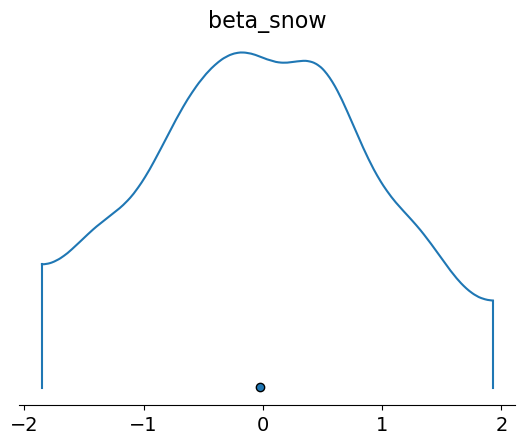

In [18]:
plot_all_prior_coefficients(model_depth_prior)

In [19]:
prior_summary = summarize_all_prior_coefficients(model_depth_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.17,2.39,0.00,7.23,0.07,0.07,1012.16,916.70,NaN
alpha,-7.01,1.45,-9.99,-4.58,0.05,0.03,1004.26,989.81,NaN
beta_snow,-0.03,1.03,-1.86,1.93,0.03,0.02,905.66,868.23,NaN


In [20]:
summary = summarize_all_posterior_coefficients(model_depth_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,0.60,0.16,0.30,0.89,0.00,0.00,4171.89,4326.09,1.0
alpha,-6.99,0.89,-8.73,-5.36,0.01,0.01,4119.14,4561.83,1.0
sigma,1.24,0.36,0.74,1.82,0.01,0.01,4109.08,4267.83,1.0


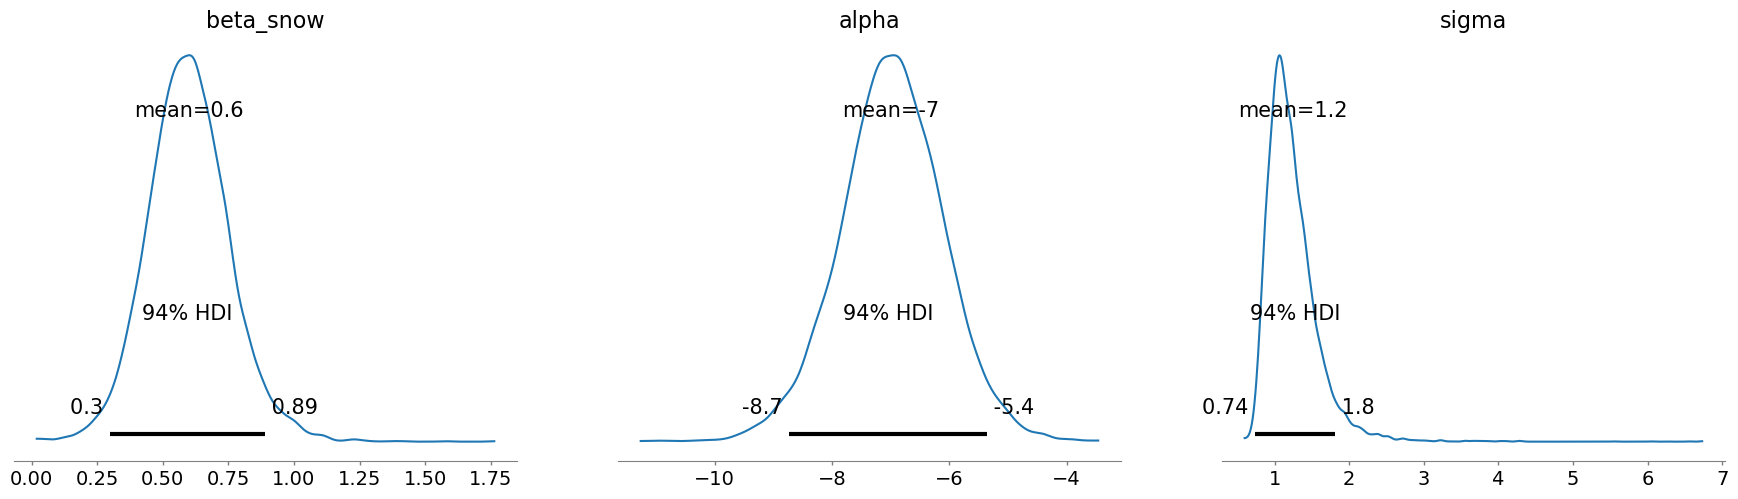

In [21]:
plot_all_posterior_coefficients(model_depth_idata)

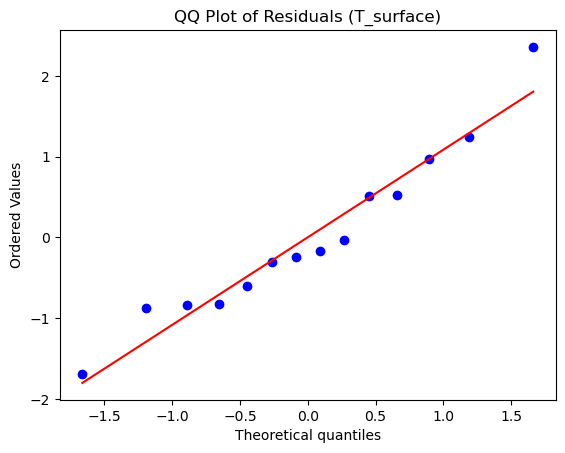

In [22]:
residuals = plot_residual_qq(
    model_depth_idata,
    T_surface,
    var_name="T_surface"
)

In [23]:
r2_table = compute_bayesian_r2(
    model_depth_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.498235,0.105141


In [24]:
loo_depth = compute_loo(model_depth_idata)
print(loo_depth)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -23.07     2.77
p_loo        2.76        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       14  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

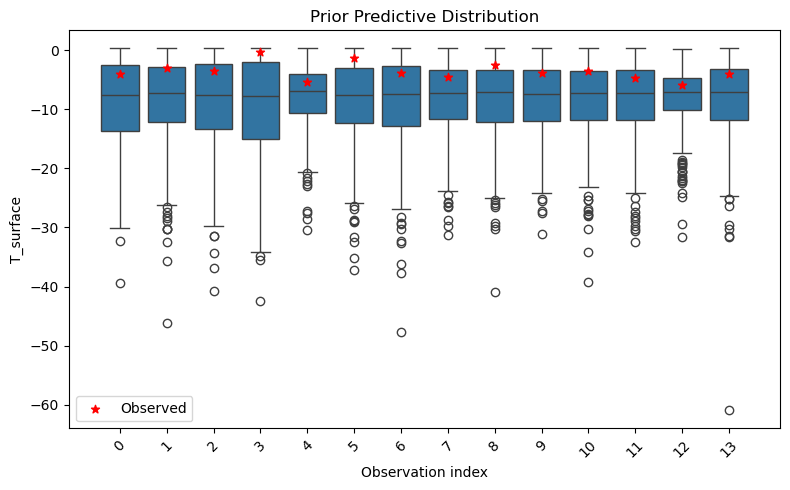

In [25]:
plot_prior_predictions(model_depth_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

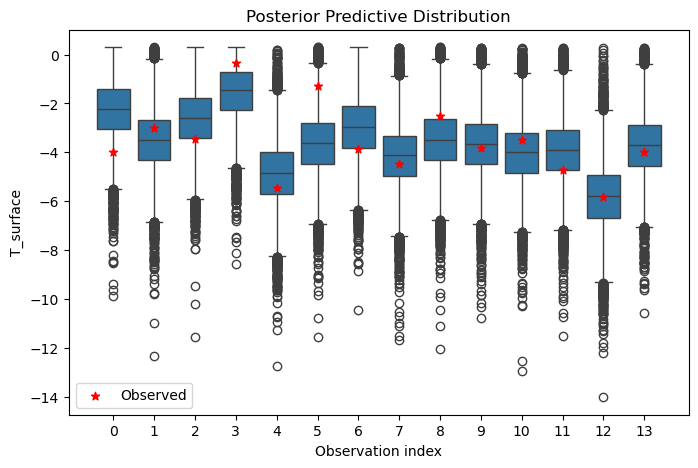

In [26]:
plot_predictions(model_depth_idata)

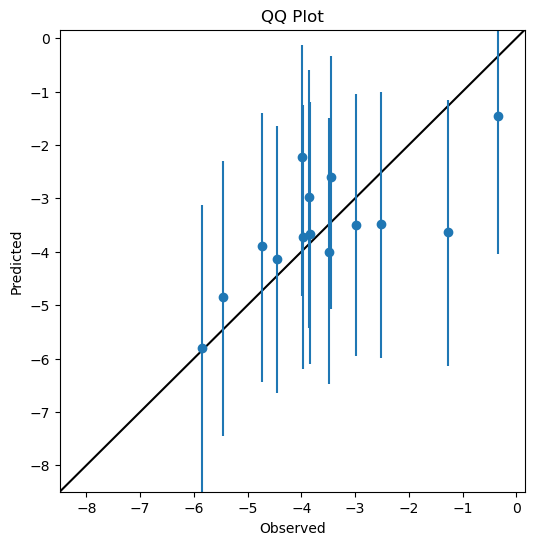

In [27]:
qqplot(model_depth_idata)

## model_topography

In [28]:
T_surface = df["T_surface"].values

with pm.Model() as model_topography:

    # -------------------------
    # Data
    # -------------------------
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-7.1,        # mean air temperature, physically surface = air when snow=0
        sigma=1.5,      # allow some variability
        upper=0.3       # truncate at upper bound of surface temp
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,       
        sigma=0.5       # small expected effect
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   # observed SD of surface temperature ≈ 2.9°C
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [29]:
model_topography_prior, model_topography_idata = run_model(model_topography)

Sampling: [T_surface, alpha, beta_cos, beta_elev, beta_sin, beta_slope, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_slope, beta_elev, beta_sin, beta_cos, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 65 seconds.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

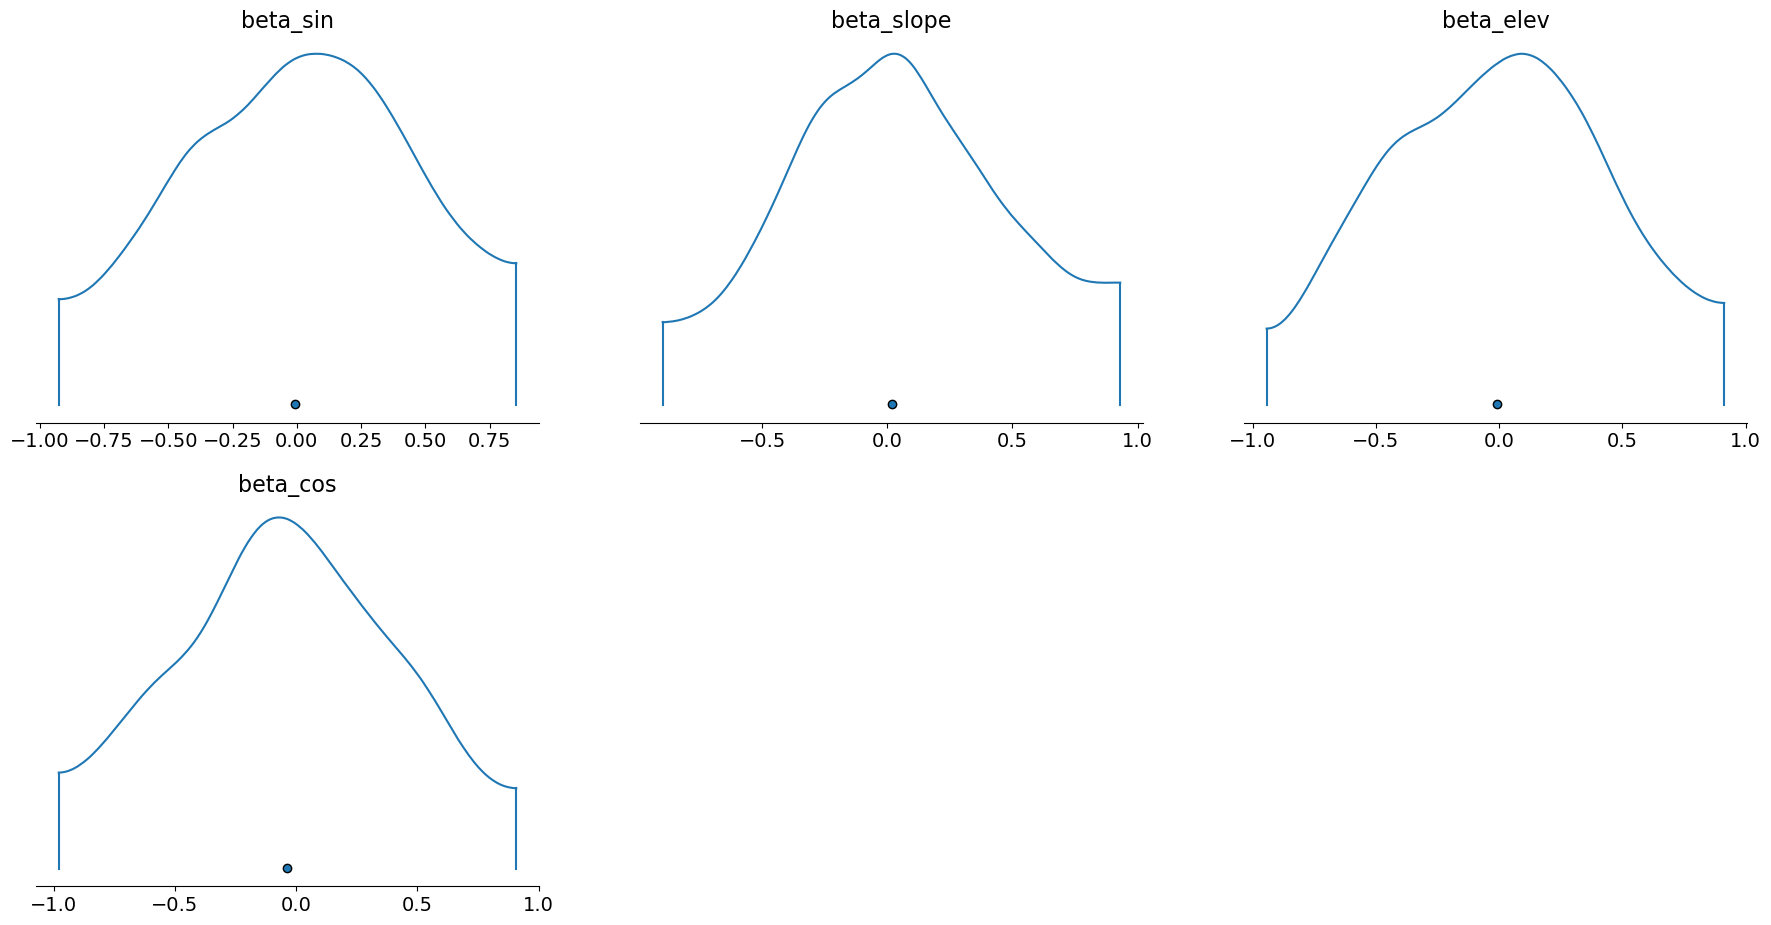

In [30]:
plot_all_prior_coefficients(model_topography_prior)

In [31]:
prior_summary = summarize_all_prior_coefficients(model_topography_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_sin,-0.01,0.49,-0.93,0.86,0.02,0.01,870.14,868.28,NaN
alpha,-7.08,1.50,-9.99,-4.37,0.05,0.04,941.66,982.80,NaN
beta_slope,0.02,0.49,-0.90,0.93,0.02,0.01,859.88,983.28,NaN
beta_elev,-0.01,0.50,-0.94,0.92,0.02,0.01,1059.65,942.40,NaN
sigma,3.10,2.36,0.01,7.42,0.07,0.07,1094.06,1014.41,NaN
beta_cos,-0.04,0.51,-0.98,0.91,0.02,0.01,966.77,775.48,NaN


In [32]:
summary = summarize_all_posterior_coefficients(model_topography_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_slope,0.14,0.13,-0.08,0.41,0.00,0.00,5884.47,3884.18,1.0
beta_elev,0.21,0.19,-0.14,0.55,0.00,0.00,4445.10,5427.95,1.0
beta_sin,-0.20,0.44,-1.03,0.64,0.01,0.00,7629.62,7660.26,1.0
beta_cos,0.31,0.43,-0.48,1.12,0.00,0.00,7824.76,7689.41,1.0
alpha,-6.17,1.40,-8.71,-3.47,0.02,0.01,5100.61,4703.88,1.0
sigma,1.89,0.76,0.89,3.25,0.01,0.02,4087.22,4061.09,1.0


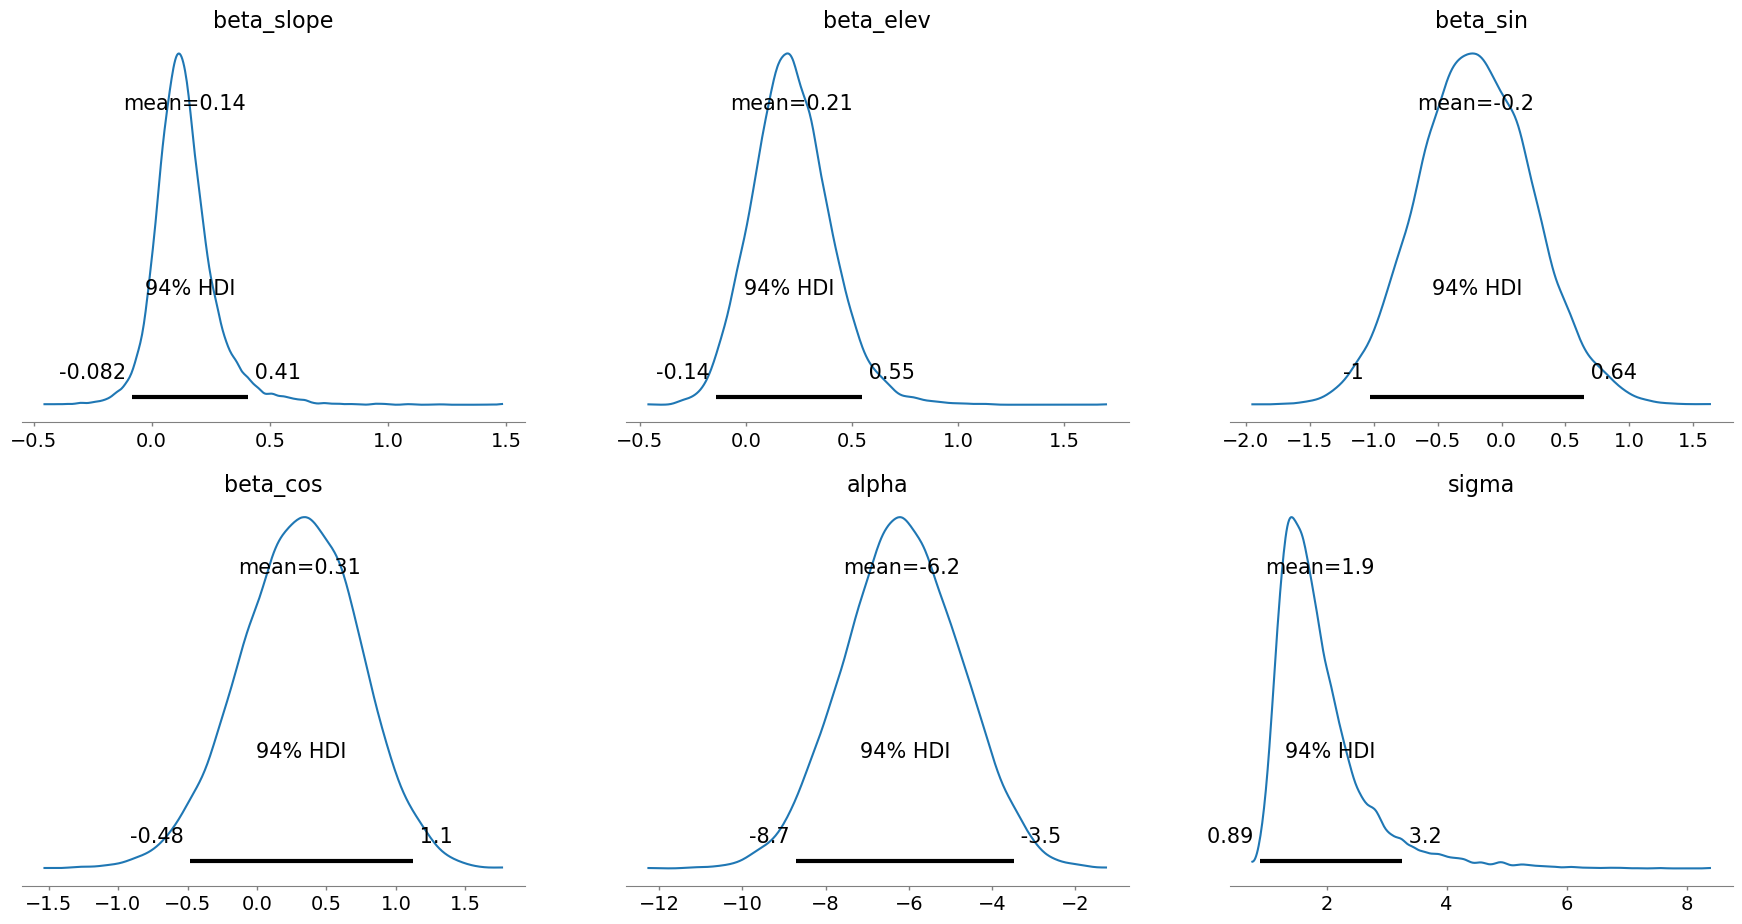

In [33]:
plot_all_posterior_coefficients(model_topography_idata)

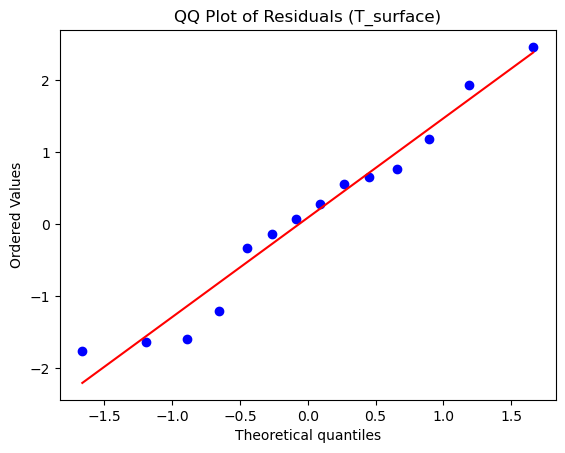

In [34]:
residuals = plot_residual_qq(
    model_topography_idata,
    T_surface,
    var_name="T_surface"
)

In [35]:
r2_table = compute_bayesian_r2(
    model_topography_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.426469,0.090642


In [36]:
loo_topography = compute_loo(model_topography_idata)
print(loo_topography)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -28.07     1.68
p_loo        3.66        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13   92.9%
   (0.70, 1]   (bad)         1    7.1%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

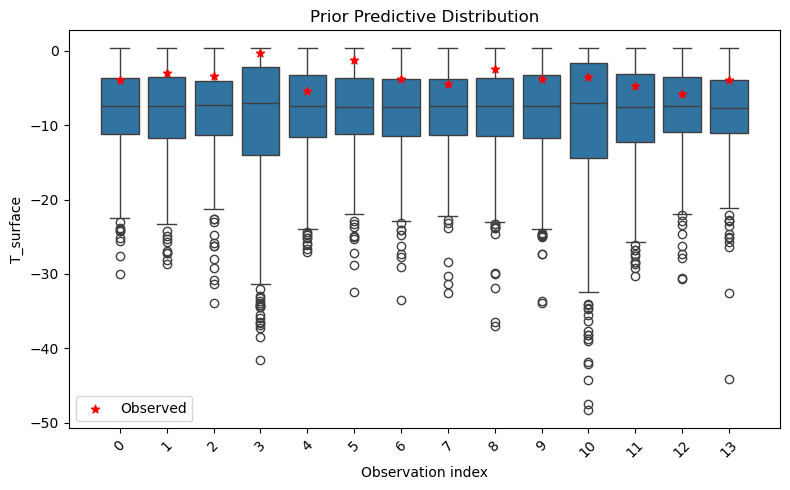

In [37]:
plot_prior_predictions(model_topography_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

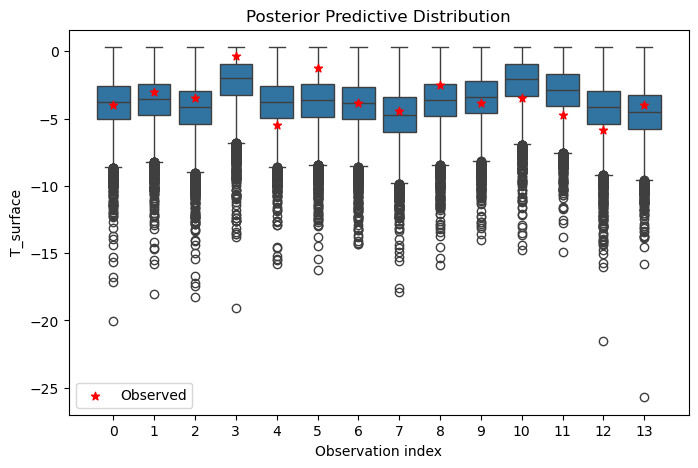

In [38]:
plot_predictions(model_topography_idata)

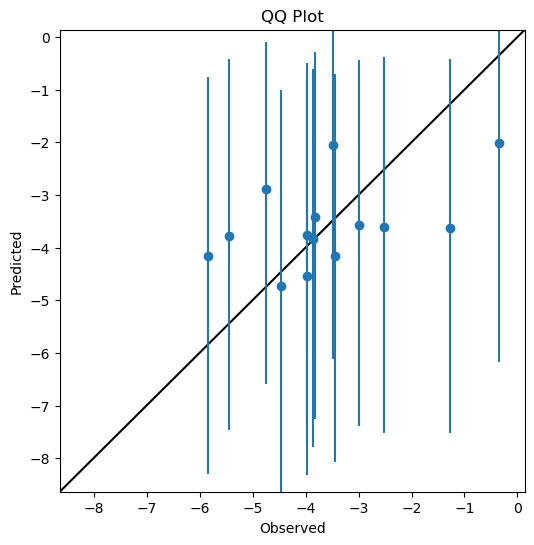

In [39]:
qqplot(model_topography_idata)

## model_density

In [40]:
T_surface = df["T_surface"].values

with pm.Model() as model_density:

    # -------------------------
    # Data
    density = pm.Data("density", df["density_01"].values) 


    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-7.1,        # mean air temperature, physically surface = air when snow=0
        sigma=1.5,      # allow some variability
        upper=0.3       # truncate at upper bound of surface temp
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_density = pm.Normal(
        "beta_density",
        mu=0,        
        sigma=1
    )


    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   # observed SD of surface temperature ≈ 2.9°C
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_density * density
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [41]:
model_density_prior, model_density_idata = run_model(model_density)

Sampling: [T_surface, alpha, beta_density, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_density, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 70 seconds.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

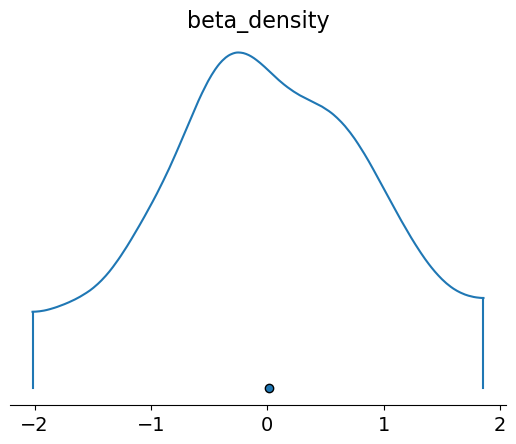

In [42]:
plot_all_prior_coefficients(model_density_prior)

In [43]:
prior_summary = summarize_all_prior_coefficients(model_density_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.24,2.43,0.00,7.56,0.08,0.06,946.97,973.27,NaN
alpha,-7.09,1.47,-9.88,-4.33,0.05,0.03,956.08,879.19,NaN
beta_density,0.02,1.01,-2.02,1.86,0.03,0.02,1040.05,959.82,NaN


In [44]:
summary = summarize_all_posterior_coefficients(model_density_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_density,0.99,0.47,0.16,1.90,0.01,0.01,3811.61,4233.98,1.0
alpha,-6.48,1.33,-9.02,-4.03,0.02,0.02,3807.65,4088.29,1.0
sigma,1.74,0.51,0.98,2.66,0.01,0.01,3889.73,4064.30,1.0


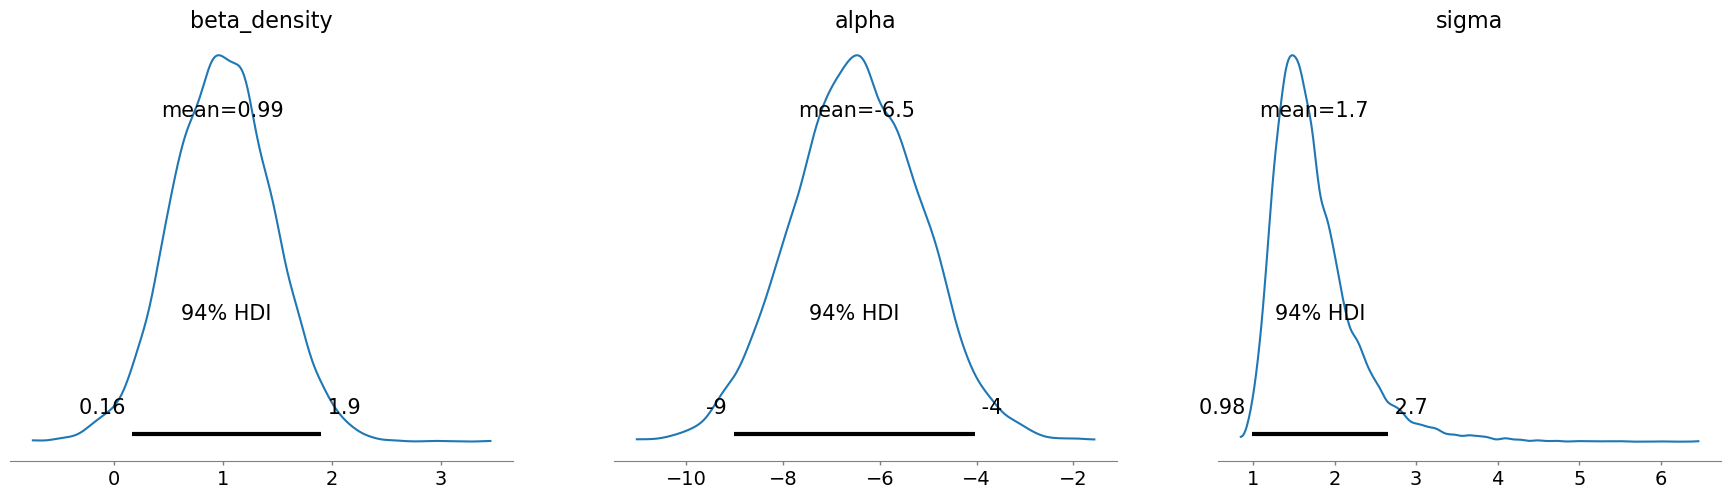

In [45]:
plot_all_posterior_coefficients(model_density_idata)

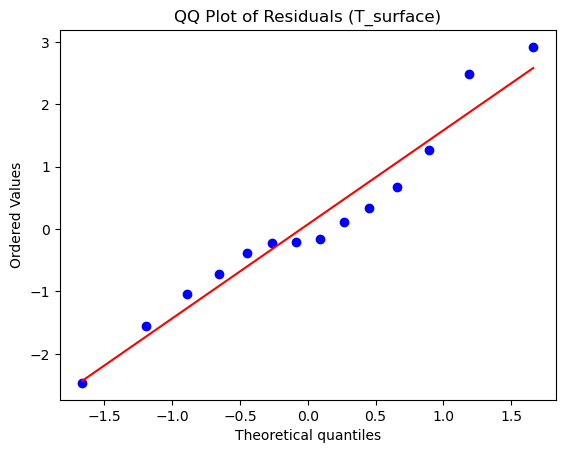

In [46]:
residuals = plot_residual_qq(
    model_density_idata,
    T_surface,
    var_name="T_surface"
)

In [47]:
r2_table = compute_bayesian_r2(
    model_density_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.355737,0.09043


In [48]:
loo_density = compute_loo(model_density_idata)
print(loo_density)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -27.02     2.45
p_loo        2.17        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       14  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

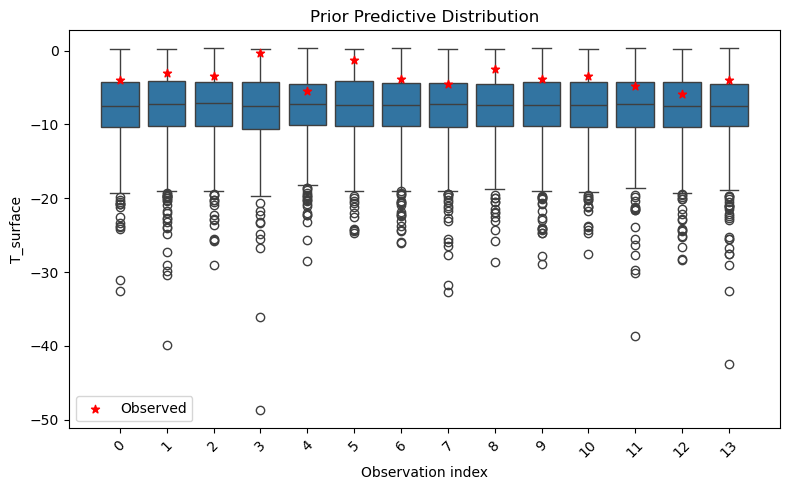

In [49]:
plot_prior_predictions(model_density_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

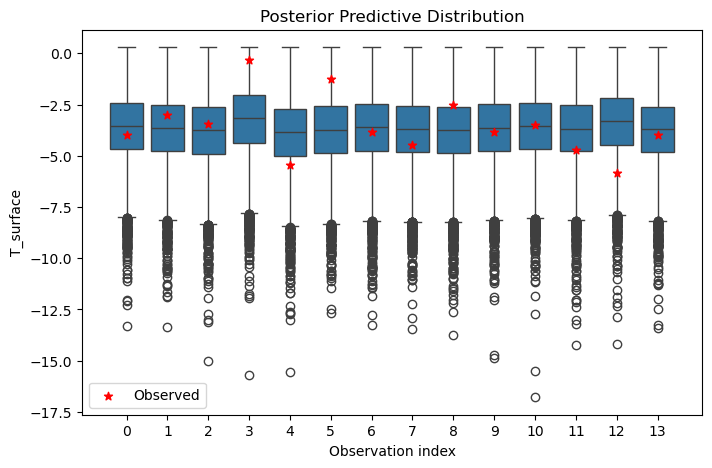

In [50]:
plot_predictions(model_density_idata)

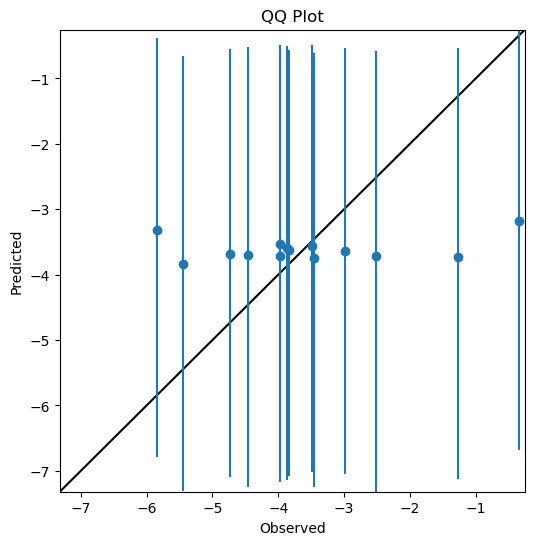

In [51]:
qqplot(model_density_idata)

## model_depth_density

In [52]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth_density:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)       
    density = pm.Data("density", df["density_01"].values) 
   
    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-7.1,        # mean air temperature, physically surface = air when snow=0
        sigma=1.5,      # allow some variability
        upper=0.3       # truncate at upper bound of surface temp
    )
    
    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   # observed SD of surface temperature ≈ 2.9°C
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,         
        sigma=1
    )

    beta_density = pm.Normal(
        "beta_density",
        mu=0,         
        sigma=1
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
        + beta_density * density
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [53]:
model_depth_density_prior, model_depth_density_idata = run_model(model_depth_density)

Sampling: [T_surface, alpha, beta_density, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma, beta_snow, beta_density]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 76 seconds.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

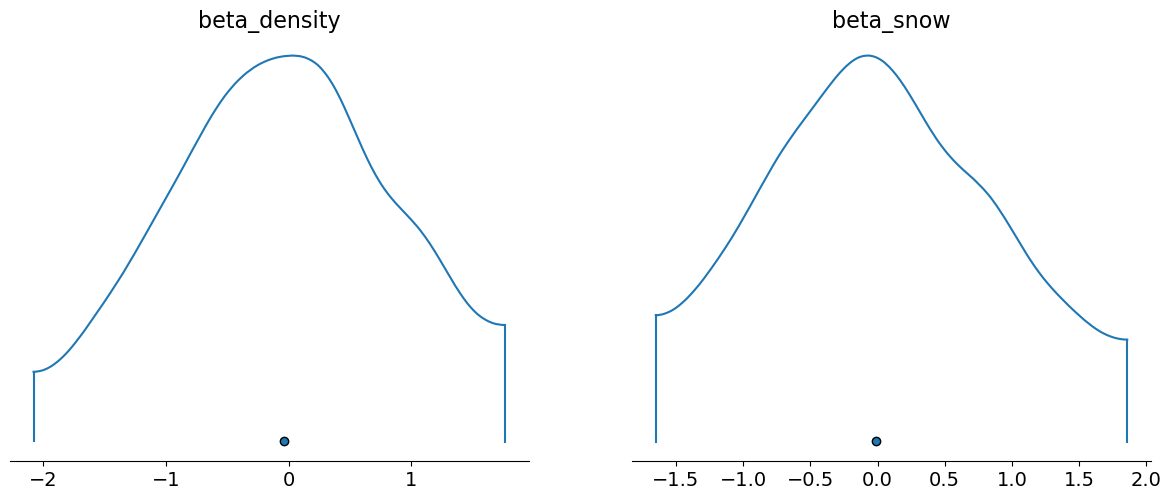

In [54]:
plot_all_prior_coefficients(model_depth_density_prior)

In [55]:
prior_summary = summarize_all_prior_coefficients(model_depth_density_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-7.05,1.48,-9.67,-4.32,0.05,0.03,959.75,857.20,NaN
beta_density,-0.04,1.02,-2.08,1.77,0.03,0.02,896.16,986.11,NaN
sigma,3.34,2.46,0.01,7.71,0.09,0.07,859.42,1021.92,NaN
beta_snow,-0.01,0.95,-1.65,1.86,0.03,0.02,921.30,943.13,NaN


In [56]:
summary = summarize_all_posterior_coefficients(model_depth_density_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,0.58,0.20,0.20,0.94,0.00,0.00,4629.48,4404.38,1.0
beta_density,0.14,0.53,-0.82,1.22,0.01,0.01,3958.61,4905.50,1.0
alpha,-7.28,1.32,-9.85,-4.85,0.02,0.02,4373.46,5048.27,1.0
sigma,1.27,0.38,0.71,1.89,0.01,0.01,4281.25,4321.57,1.0


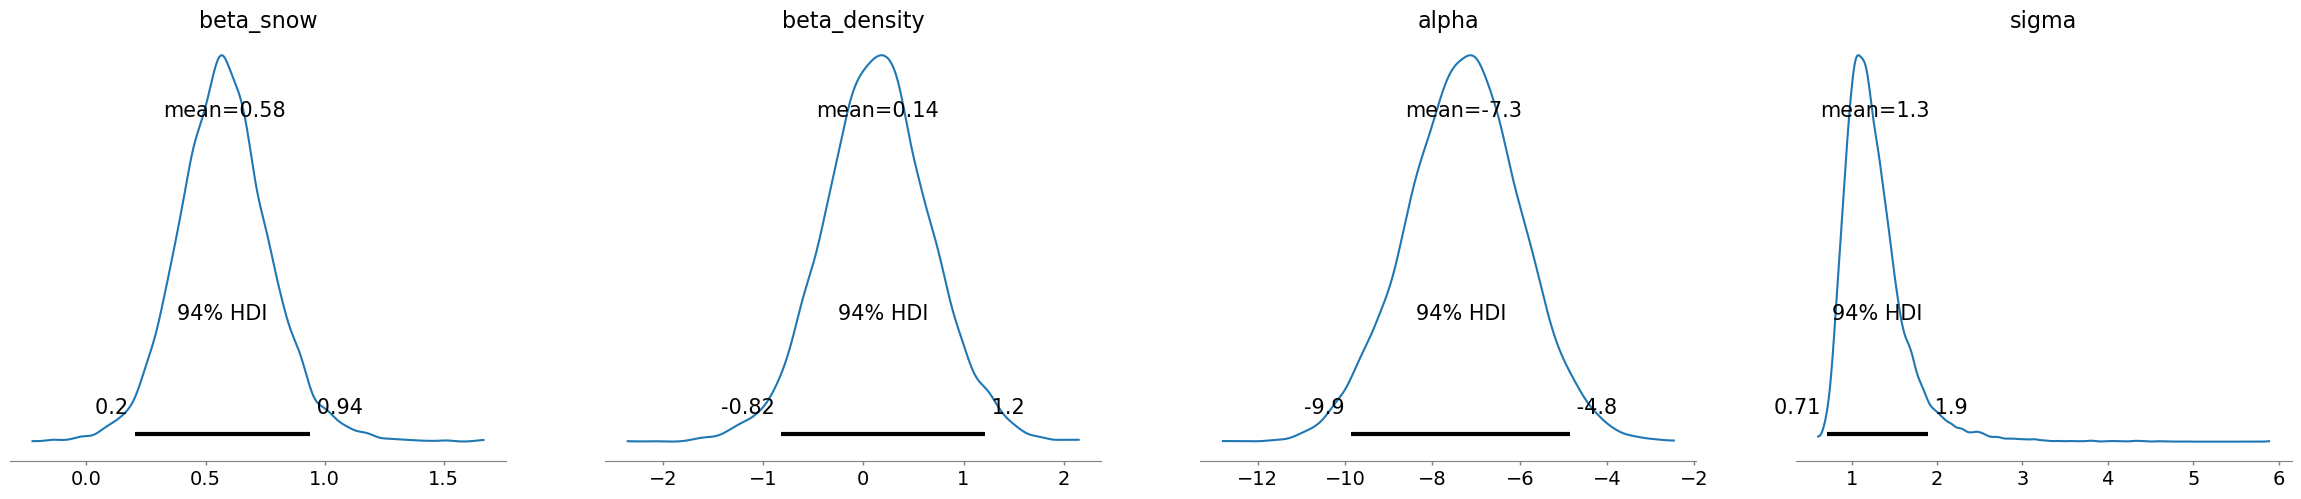

In [57]:
plot_all_posterior_coefficients(model_depth_density_idata)

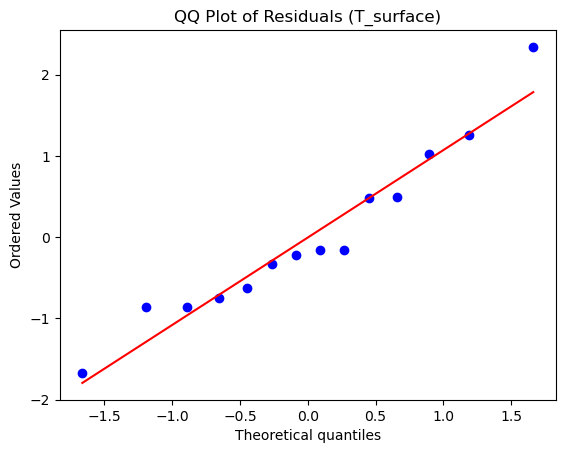

In [58]:
residuals = plot_residual_qq(
    model_depth_density_idata,
    T_surface,
    var_name="T_surface"
)

In [59]:
r2_table = compute_bayesian_r2(
    model_depth_density_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.491655,0.110355


In [60]:
loo_depth_density = compute_loo(model_depth_density_idata)
print(loo_depth_density)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -23.57     2.77
p_loo        3.11        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       14  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

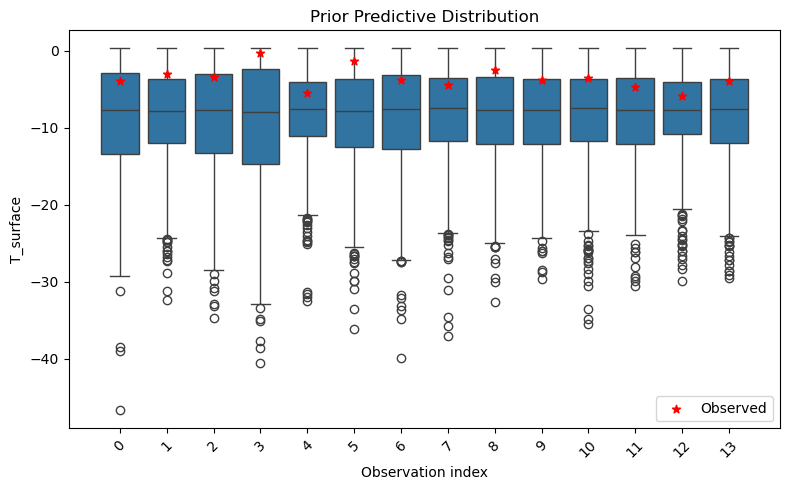

In [61]:
plot_prior_predictions(model_depth_density_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

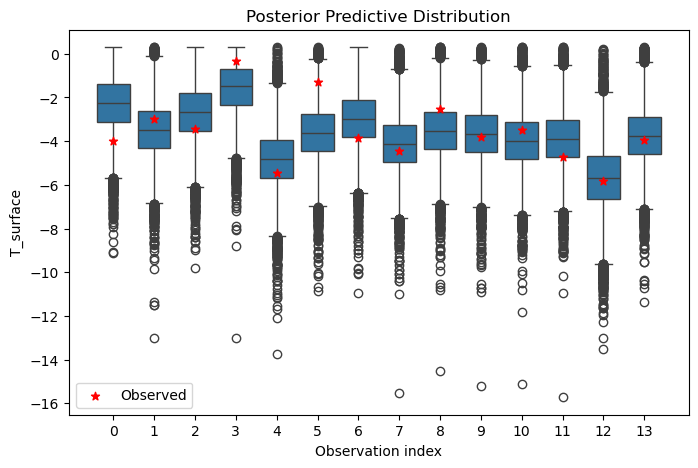

In [62]:
plot_predictions(model_depth_density_idata)

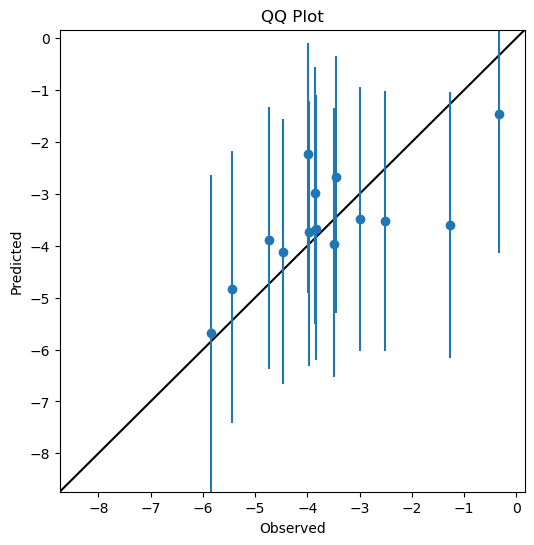

In [63]:
qqplot(model_depth_density_idata)

## model_depth_topography

In [64]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth_topography:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)      
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-7.1,        # mean air temperature, physically surface = air when snow=0
        sigma=1.5,      # allow some variability
        upper=0.3       # truncate at upper bound of surface temp
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,         
        sigma=1
    )

    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,         
        sigma=0.5       # small expected effect
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   # observed SD of surface temperature ≈ 2.9°C
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [65]:
model_depth_topography_prior, model_depth_topography_idata = run_model(model_depth_topography)

Sampling: [T_surface, alpha, beta_cos, beta_elev, beta_sin, beta_slope, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, beta_slope, beta_elev, beta_sin, beta_cos, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 86 seconds.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

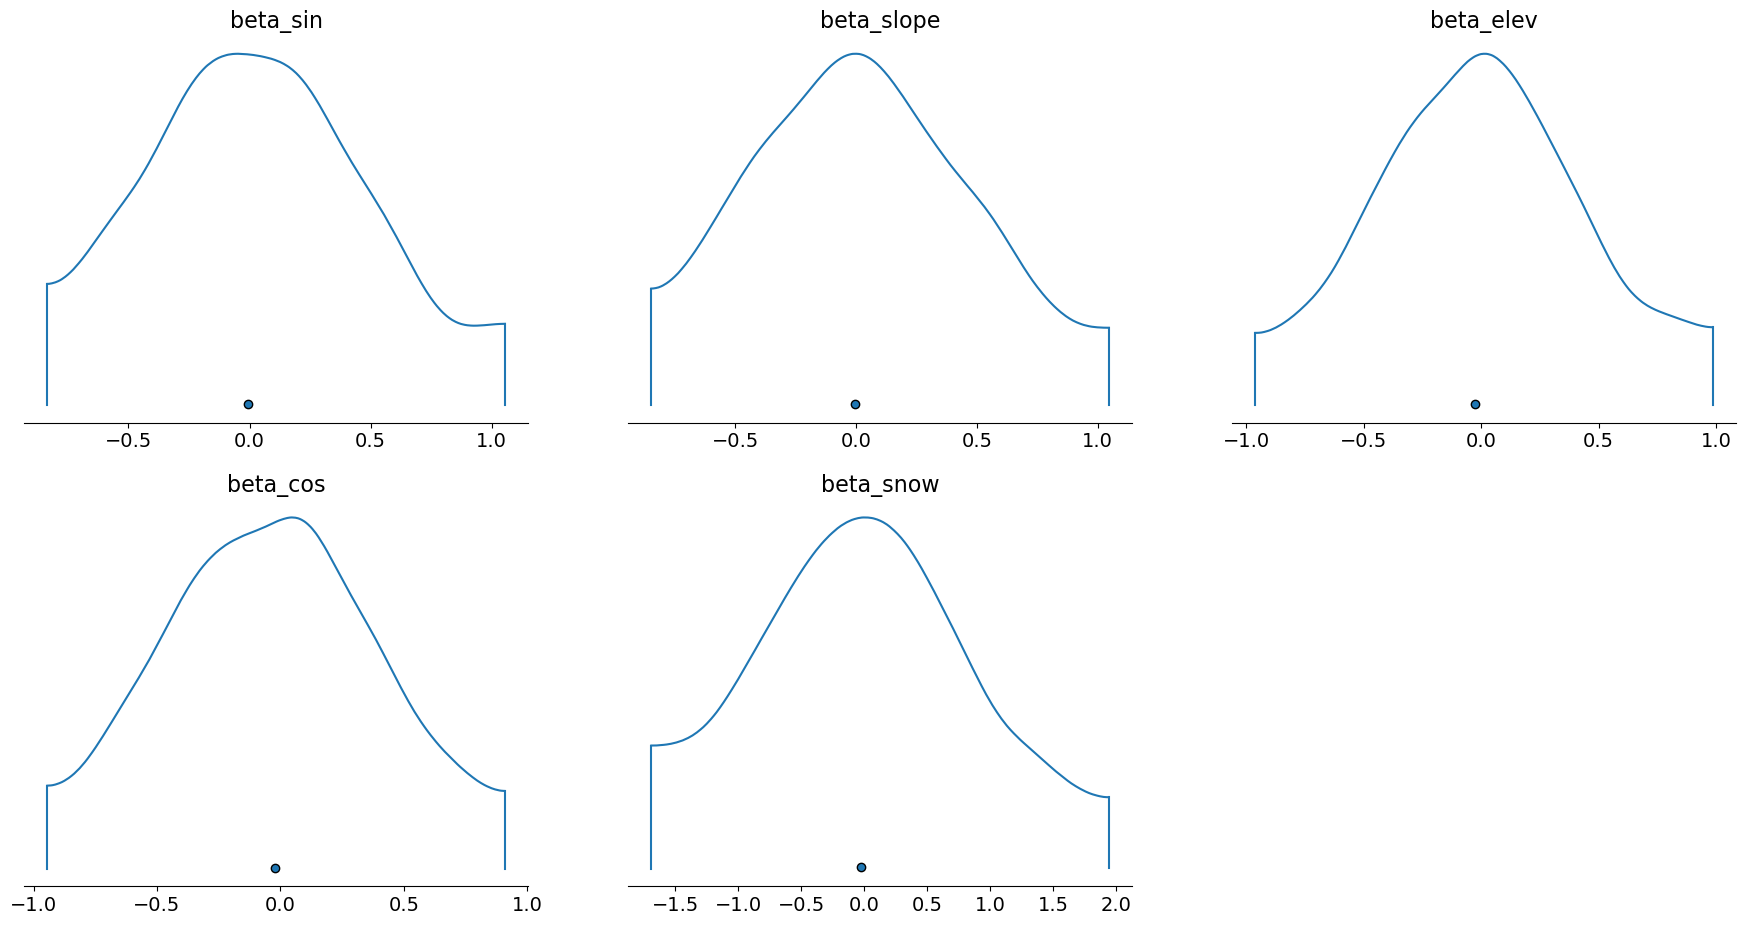

In [66]:
plot_all_prior_coefficients(model_depth_topography_prior)

In [67]:
prior_summary = summarize_all_prior_coefficients(model_depth_topography_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_sin,-0.00,0.50,-0.84,1.06,0.02,0.01,932.47,935.13,NaN
alpha,-7.05,1.51,-9.81,-4.20,0.05,0.03,983.28,976.16,NaN
beta_slope,-0.00,0.50,-0.85,1.05,0.02,0.01,966.20,905.52,NaN
beta_elev,-0.02,0.50,-0.96,0.99,0.02,0.01,1088.85,887.16,NaN
sigma,3.22,2.50,0.00,7.93,0.08,0.07,1058.82,859.25,NaN
beta_cos,-0.02,0.49,-0.95,0.91,0.02,0.01,1007.09,981.99,NaN
beta_snow,-0.03,0.97,-1.69,1.95,0.03,0.03,937.04,838.42,NaN


In [68]:
summary = summarize_all_posterior_coefficients(model_depth_topography_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,0.56,0.23,0.16,0.99,0.00,0.01,6806.26,4900.57,1.0
beta_slope,0.09,0.09,-0.07,0.25,0.00,0.00,6469.00,3831.50,1.0
beta_elev,-0.07,0.18,-0.40,0.28,0.00,0.00,6007.54,5994.98,1.0
beta_sin,-0.12,0.40,-0.83,0.70,0.00,0.00,10185.16,7970.54,1.0
beta_cos,0.22,0.38,-0.47,0.96,0.00,0.00,10412.81,7774.08,1.0
alpha,-6.60,1.37,-9.32,-4.15,0.02,0.01,7133.13,5324.29,1.0
sigma,1.35,0.56,0.71,2.22,0.01,0.03,3922.01,3145.18,1.0


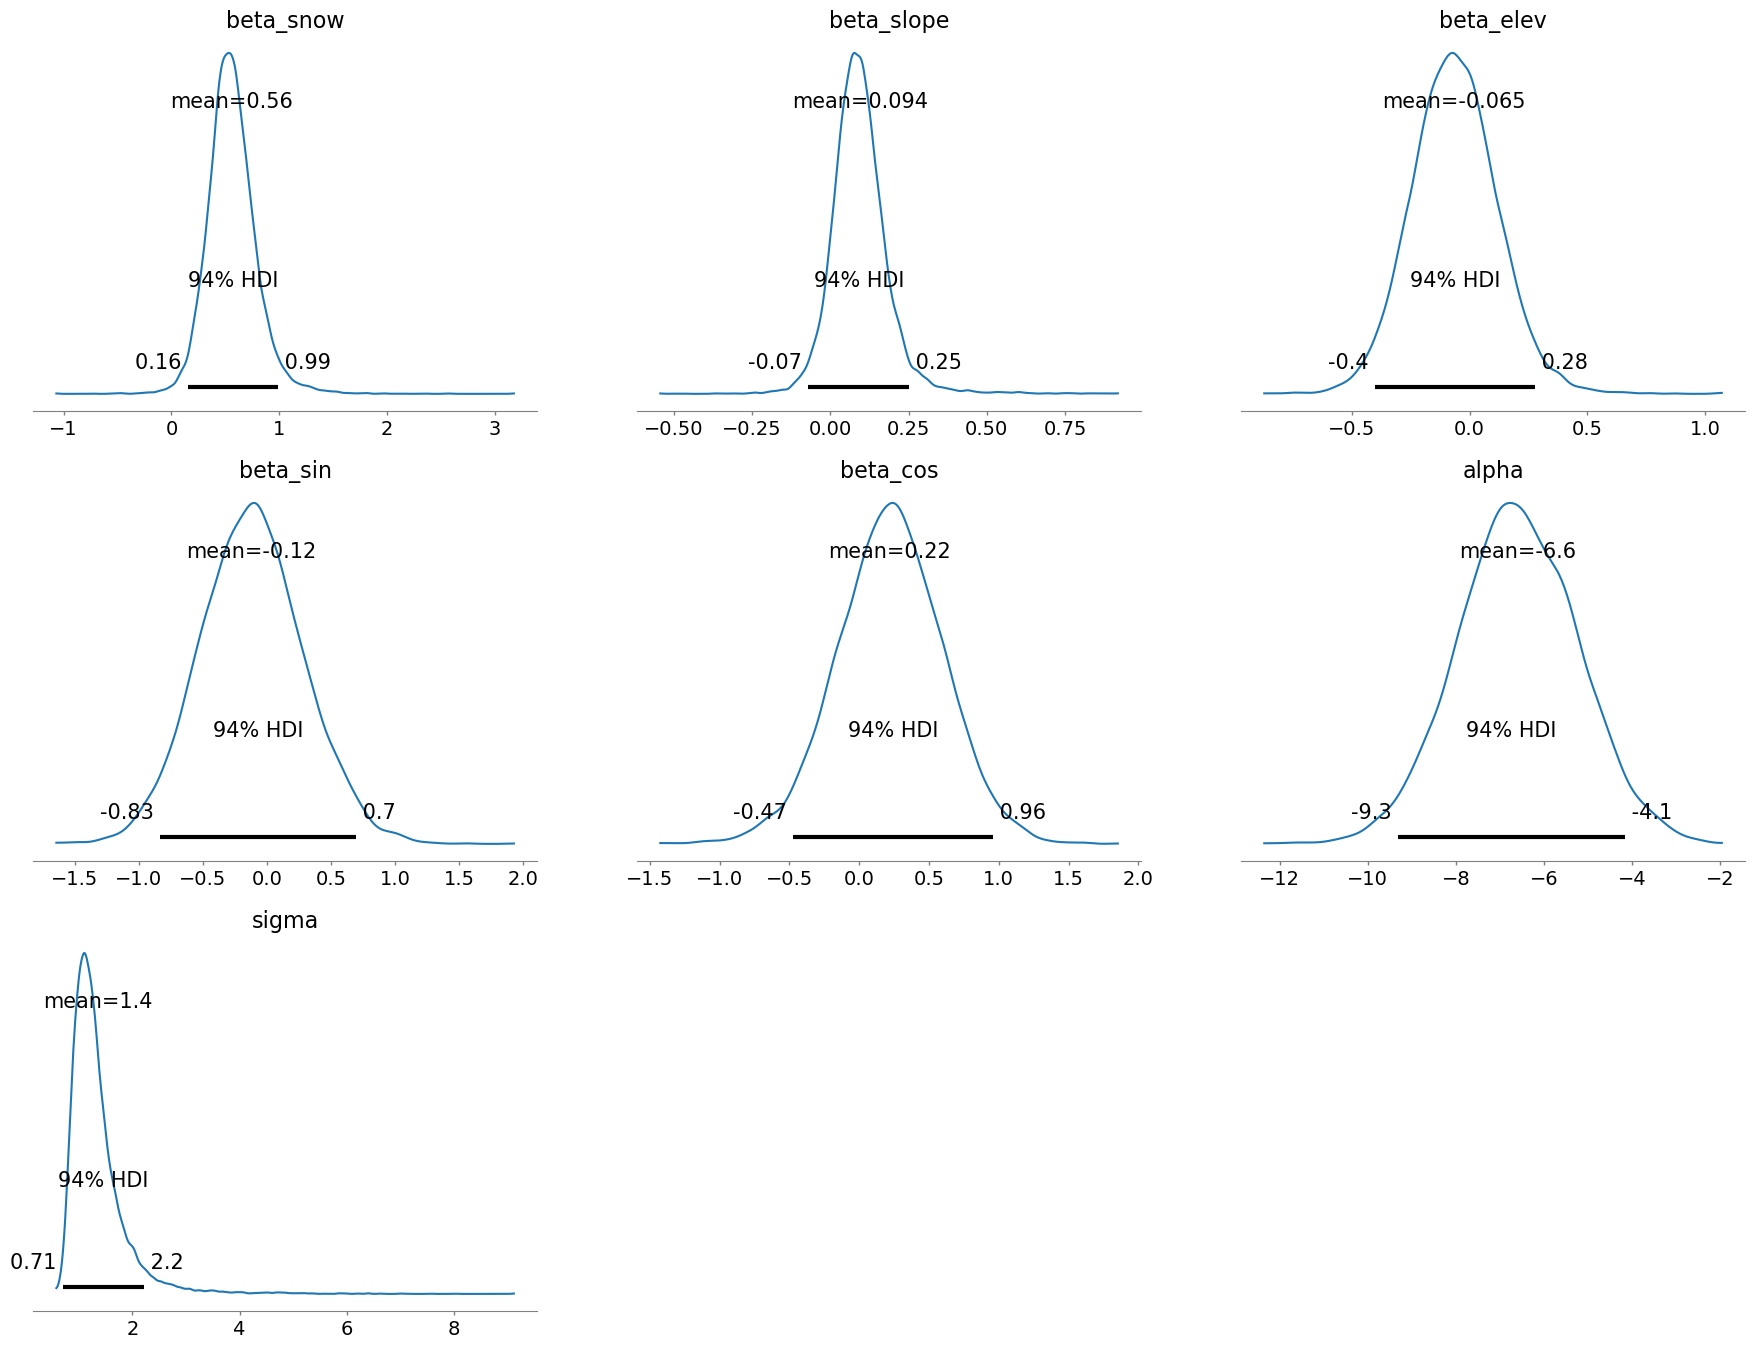

In [69]:
plot_all_posterior_coefficients(model_depth_topography_idata)

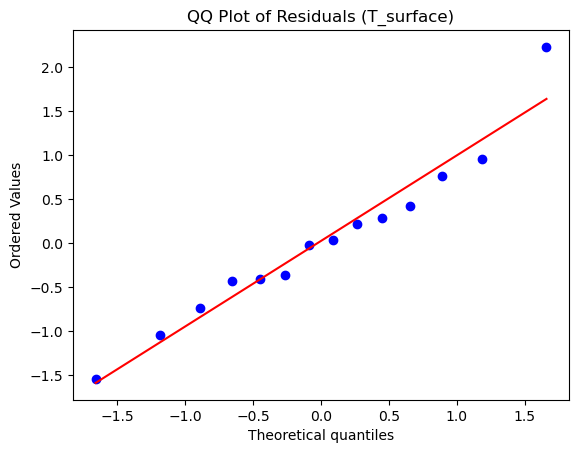

In [70]:
residuals = plot_residual_qq(
    model_depth_topography_idata,
    T_surface,
    var_name="T_surface"
)

In [71]:
r2_table = compute_bayesian_r2(
    model_depth_topography_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.541396,0.101108


In [72]:
loo_depth_topography = compute_loo(model_depth_topography_idata)
print(loo_depth_topography)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -24.49     2.64
p_loo        4.34        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13   92.9%
   (0.70, 1]   (bad)         1    7.1%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

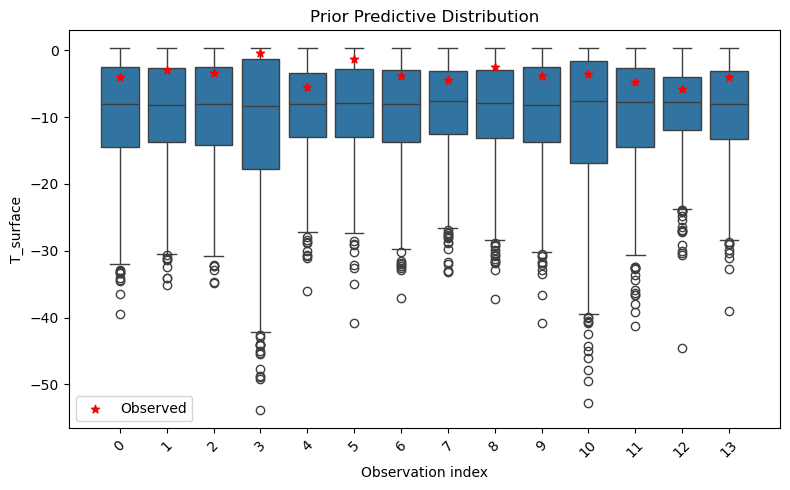

In [73]:
plot_prior_predictions(model_depth_topography_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

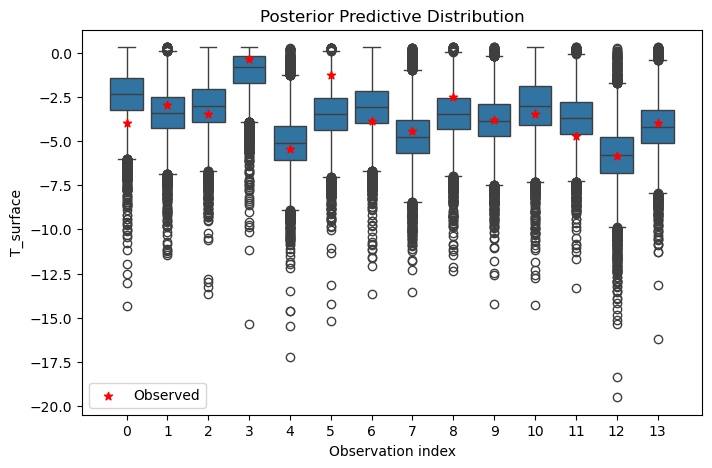

In [74]:
plot_predictions(model_depth_topography_idata)

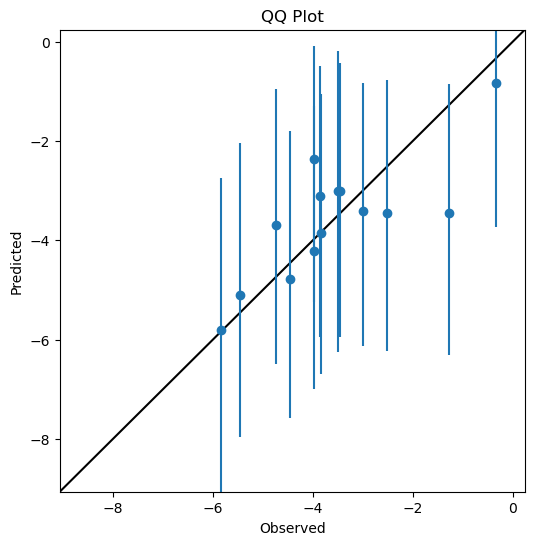

In [75]:
qqplot(model_depth_topography_idata)

## model_density_topography

In [76]:
T_surface = df["T_surface"].values

with pm.Model() as model_density_topography:

    # -------------------------
    # Data
    # -------------------------
    density = pm.Data("density", df["density_01"].values) 
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-7.1,        # mean air temperature, physically surface = air when snow=0
        sigma=1.5,      # allow some variability
        upper=0.3       # truncate at upper bound of surface temp
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_density = pm.Normal(
        "beta_density",
        mu=0,        
        sigma=1
    )

    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,         
        sigma=0.5       # small expected effect
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   # observed SD of surface temperature ≈ 2.9°C
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_density * density
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [77]:
model_density_topography_prior, model_density_topography_idata = run_model(model_density_topography)

Sampling: [T_surface, alpha, beta_cos, beta_density, beta_elev, beta_sin, beta_slope, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_density, beta_slope, beta_elev, beta_sin, beta_cos, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 105 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

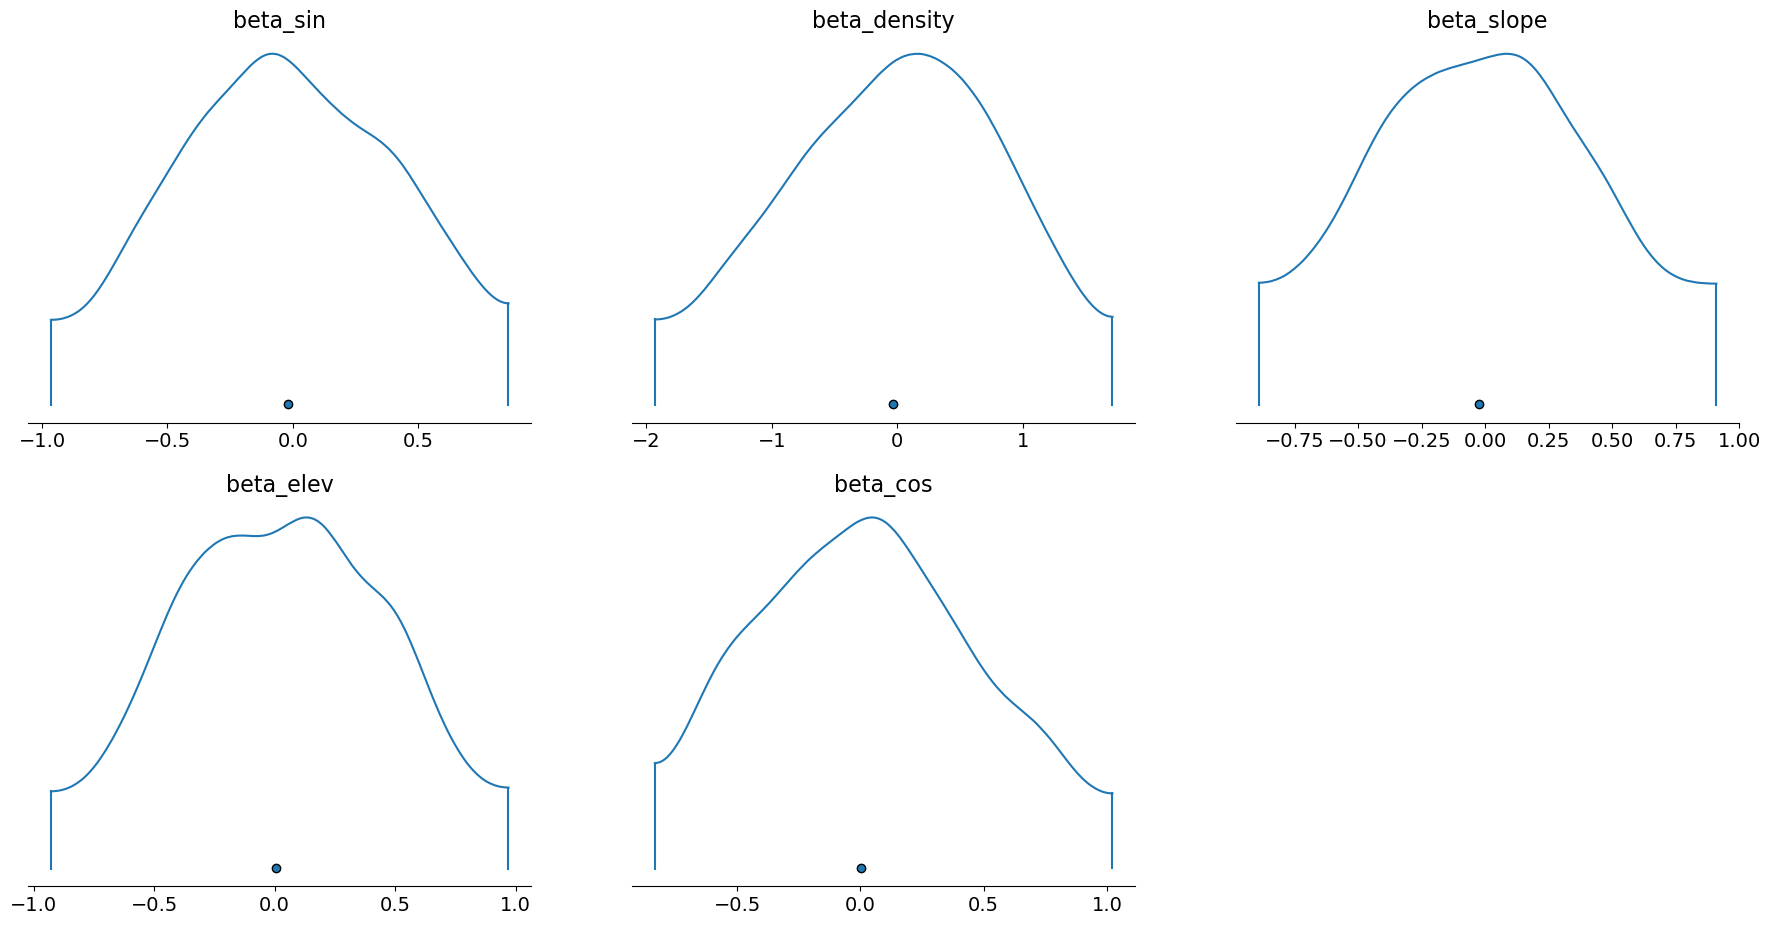

In [78]:
plot_all_prior_coefficients(model_density_topography_prior)

In [79]:
prior_summary = summarize_all_prior_coefficients(model_density_topography_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_sin,-0.02,0.50,-0.97,0.86,0.02,0.01,899.63,880.24,NaN
alpha,-7.10,1.54,-9.80,-4.01,0.05,0.03,1031.67,880.24,NaN
beta_density,-0.04,0.98,-1.93,1.72,0.03,0.02,1087.13,1006.34,NaN
beta_slope,-0.03,0.49,-0.89,0.91,0.01,0.01,1159.97,881.77,NaN
beta_elev,0.01,0.50,-0.93,0.97,0.02,0.01,1015.68,1025.21,NaN
sigma,3.17,2.37,0.00,7.36,0.08,0.06,960.08,923.44,NaN
beta_cos,0.00,0.50,-0.84,1.02,0.02,0.01,987.18,741.01,NaN


In [80]:
summary = summarize_all_posterior_coefficients(model_density_topography_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_density,0.70,0.77,-0.79,2.11,0.01,0.01,6480.75,5954.98,1.0
beta_slope,0.14,0.13,-0.08,0.38,0.00,0.00,4985.29,2774.80,1.0
beta_elev,0.03,0.28,-0.47,0.57,0.00,0.00,5776.34,6507.01,1.0
beta_sin,-0.23,0.44,-1.07,0.59,0.00,0.00,8460.23,7082.26,1.0
beta_cos,0.25,0.43,-0.56,1.05,0.00,0.00,9590.38,7804.84,1.0
alpha,-6.52,1.41,-9.05,-3.74,0.02,0.01,8832.13,6234.90,1.0
sigma,1.82,0.75,0.90,3.18,0.02,0.02,3347.94,2779.96,1.0


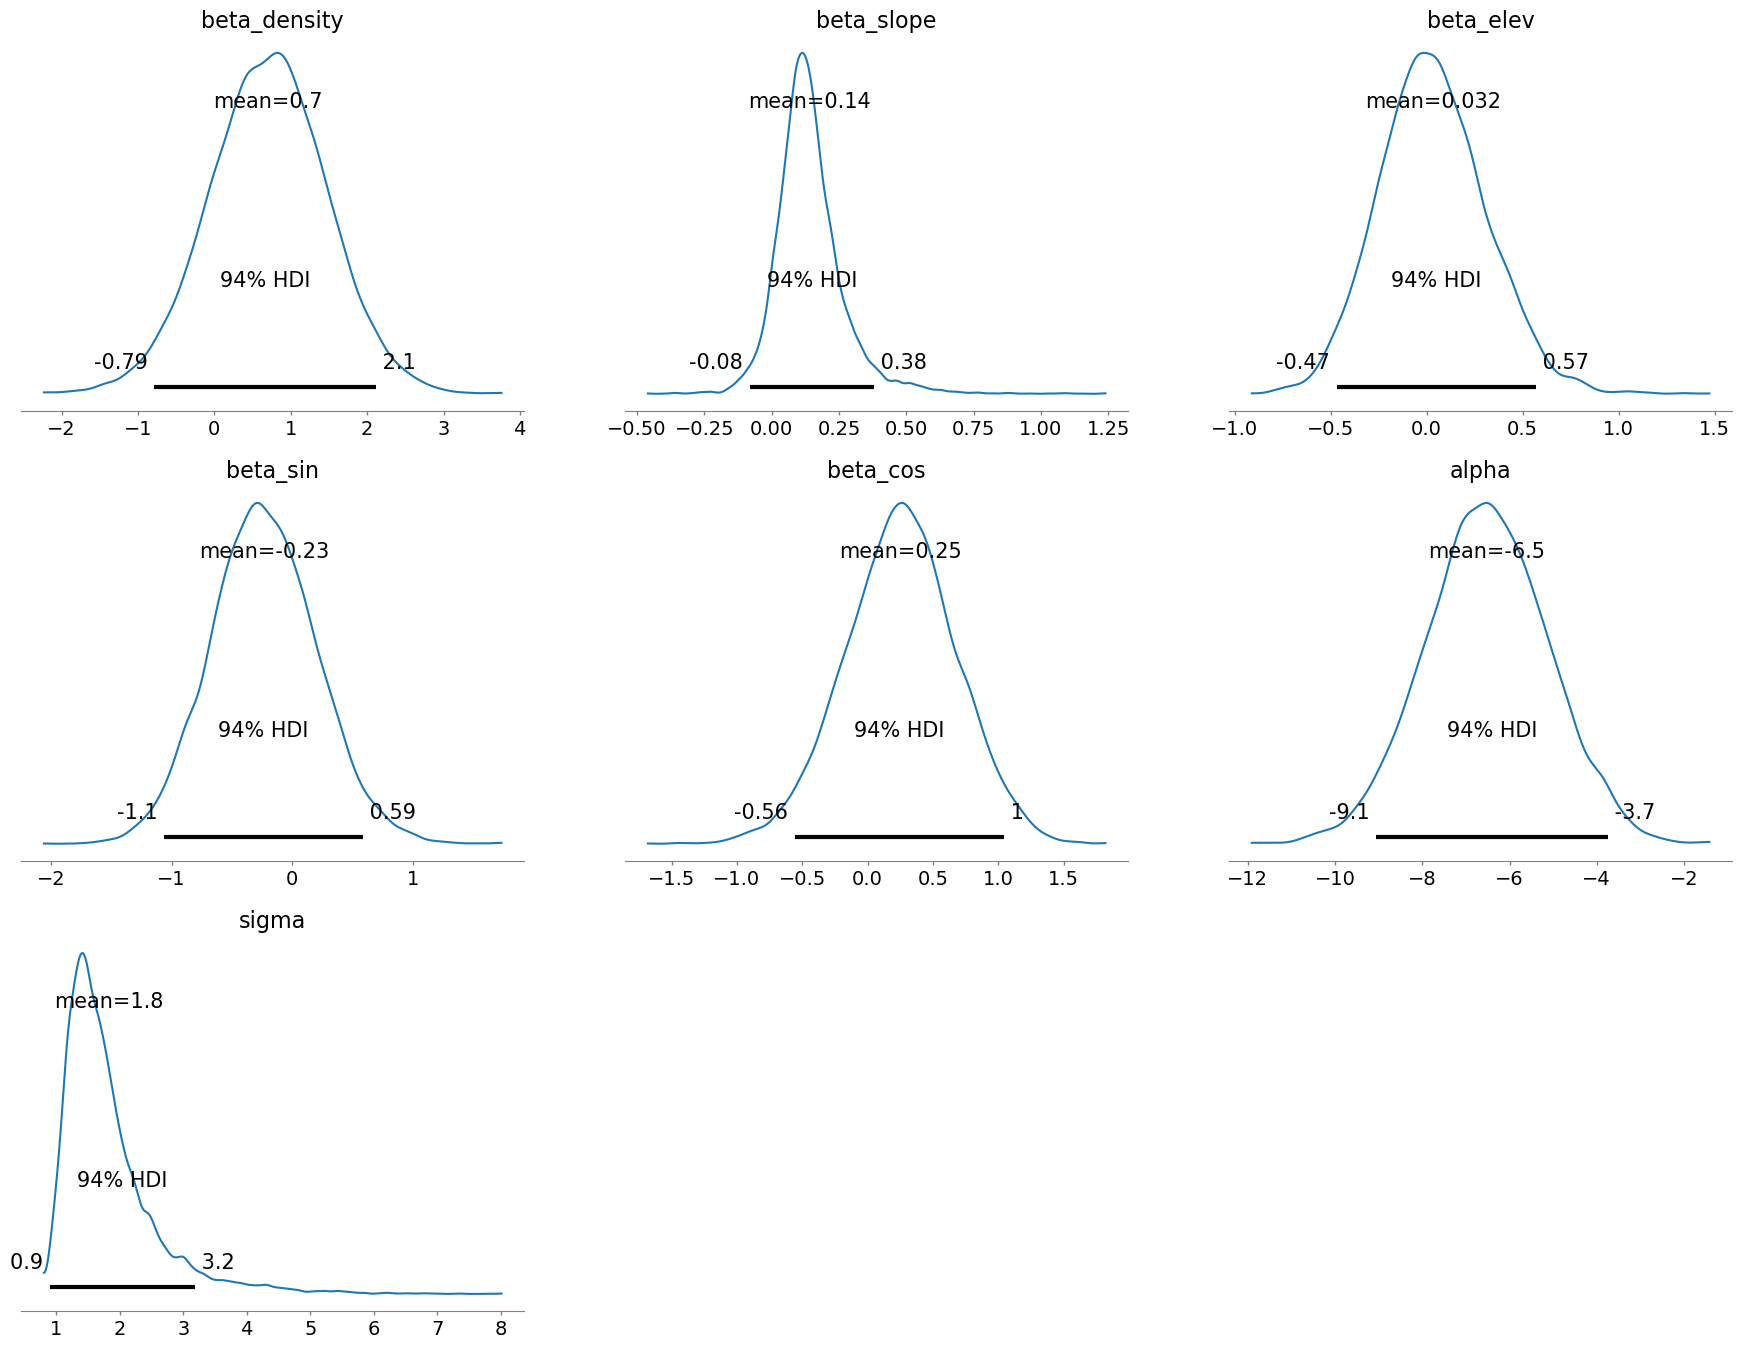

In [81]:
plot_all_posterior_coefficients(model_density_topography_idata)

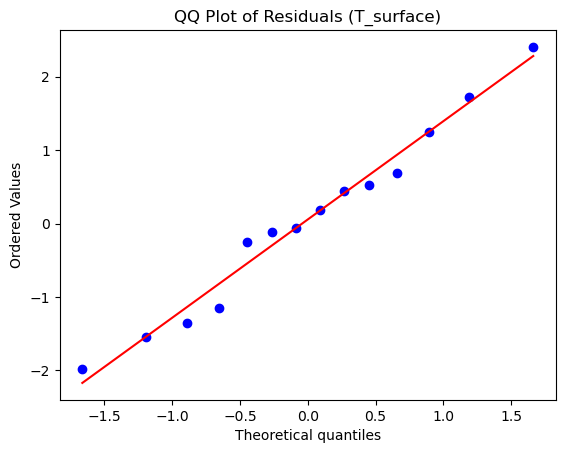

In [82]:
residuals = plot_residual_qq(
    model_density_topography_idata,
    T_surface,
    var_name="T_surface"
)

In [83]:
r2_table = compute_bayesian_r2(
    model_density_topography_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.429329,0.092064


In [84]:
loo_density_topography = compute_loo(model_density_topography_idata)
print(loo_density_topography)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -27.69     1.86
p_loo        3.88        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       14  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

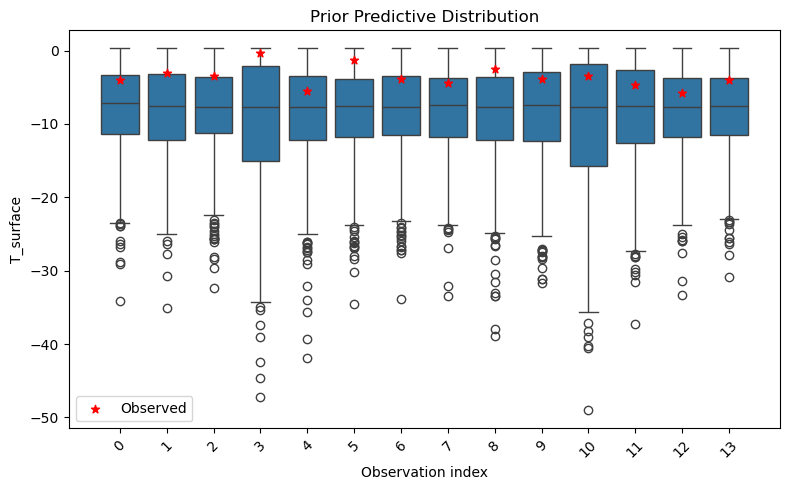

In [85]:
plot_prior_predictions(model_density_topography_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

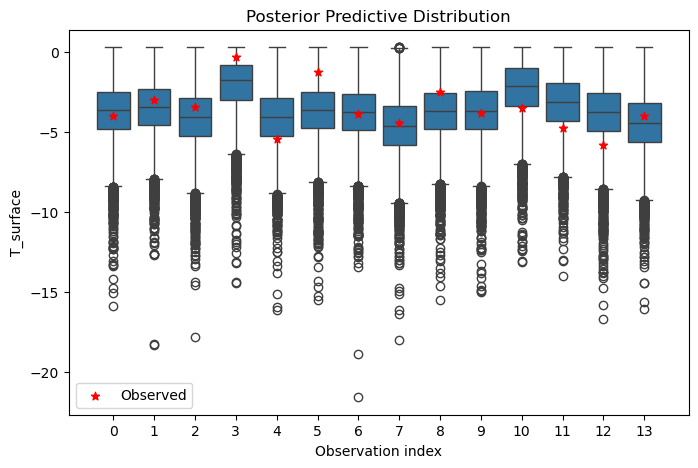

In [86]:
plot_predictions(model_density_topography_idata)

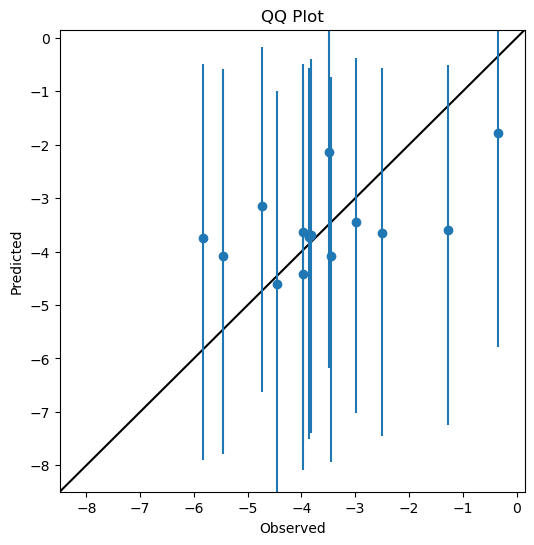

In [87]:
qqplot(model_density_topography_idata)

## model_depth_density_topography

In [88]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth_density_topography:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)      
    density = pm.Data("density", df["density_01"].values) 
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-7.1,        # mean air temperature, physically surface = air when snow=0
        sigma=1.5,      # allow some variability
        upper=0.3       # truncate at upper bound of surface temp
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,        
        sigma=1
    )

    beta_density = pm.Normal(
        "beta_density",
        mu=0,         
        sigma=1
    )

    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,         
        sigma=0.5       
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   # observed SD of surface temperature ≈ 2.9°C
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
        + beta_density * density
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [89]:
model_depth_density_topography_prior, model_depth_density_topography_idata = run_model(model_depth_density_topography)

Sampling: [T_surface, alpha, beta_cos, beta_density, beta_elev, beta_sin, beta_slope, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, beta_density, beta_slope, beta_elev, beta_sin, beta_cos, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 115 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

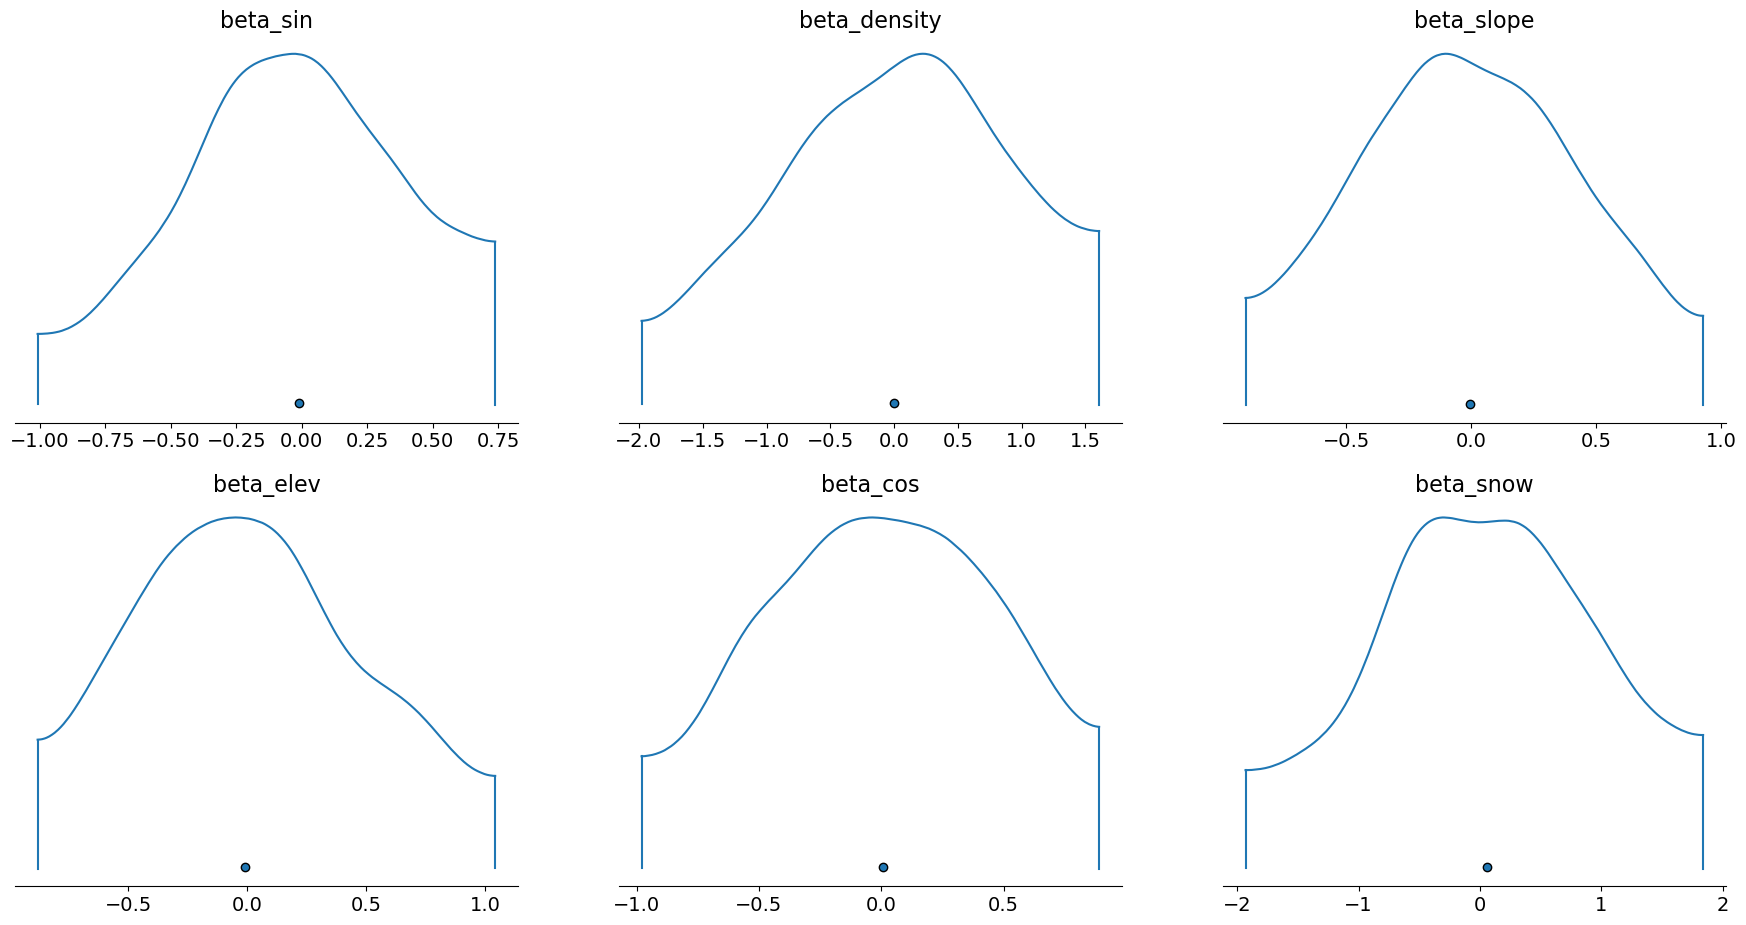

In [90]:
plot_all_prior_coefficients(model_depth_density_topography_prior)

In [91]:
prior_summary = summarize_all_prior_coefficients(model_depth_density_topography_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_sin,-0.01,0.47,-1.01,0.74,0.01,0.01,998.47,916.61,NaN
alpha,-7.05,1.49,-9.72,-4.12,0.05,0.03,988.69,990.32,NaN
beta_density,0.00,0.99,-1.98,1.61,0.03,0.02,991.69,938.49,NaN
beta_slope,-0.01,0.50,-0.91,0.93,0.02,0.01,1021.11,936.12,NaN
beta_elev,-0.01,0.52,-0.88,1.04,0.02,0.01,845.01,905.11,NaN
sigma,3.15,2.40,0.02,7.41,0.08,0.07,934.17,741.04,NaN
beta_cos,0.01,0.51,-0.98,0.89,0.02,0.01,992.12,780.66,NaN
beta_snow,0.06,1.02,-1.93,1.84,0.03,0.02,932.96,847.04,NaN


In [92]:
summary = summarize_all_posterior_coefficients(model_depth_density_topography_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,0.54,0.24,0.11,0.98,0.00,0.00,7003.46,5205.49,1.0
beta_density,0.31,0.72,-1.03,1.68,0.01,0.01,5615.56,7297.97,1.0
beta_slope,0.10,0.09,-0.06,0.27,0.00,0.00,5778.63,3756.60,1.0
beta_elev,-0.13,0.25,-0.59,0.33,0.00,0.00,5483.42,6875.09,1.0
beta_sin,-0.15,0.41,-0.87,0.67,0.00,0.00,9242.25,7885.78,1.0
beta_cos,0.19,0.38,-0.53,0.89,0.00,0.00,9317.35,8420.39,1.0
alpha,-6.77,1.44,-9.45,-4.03,0.02,0.01,7592.27,5506.76,1.0
sigma,1.36,0.56,0.66,2.26,0.01,0.02,4292.49,3095.38,1.0


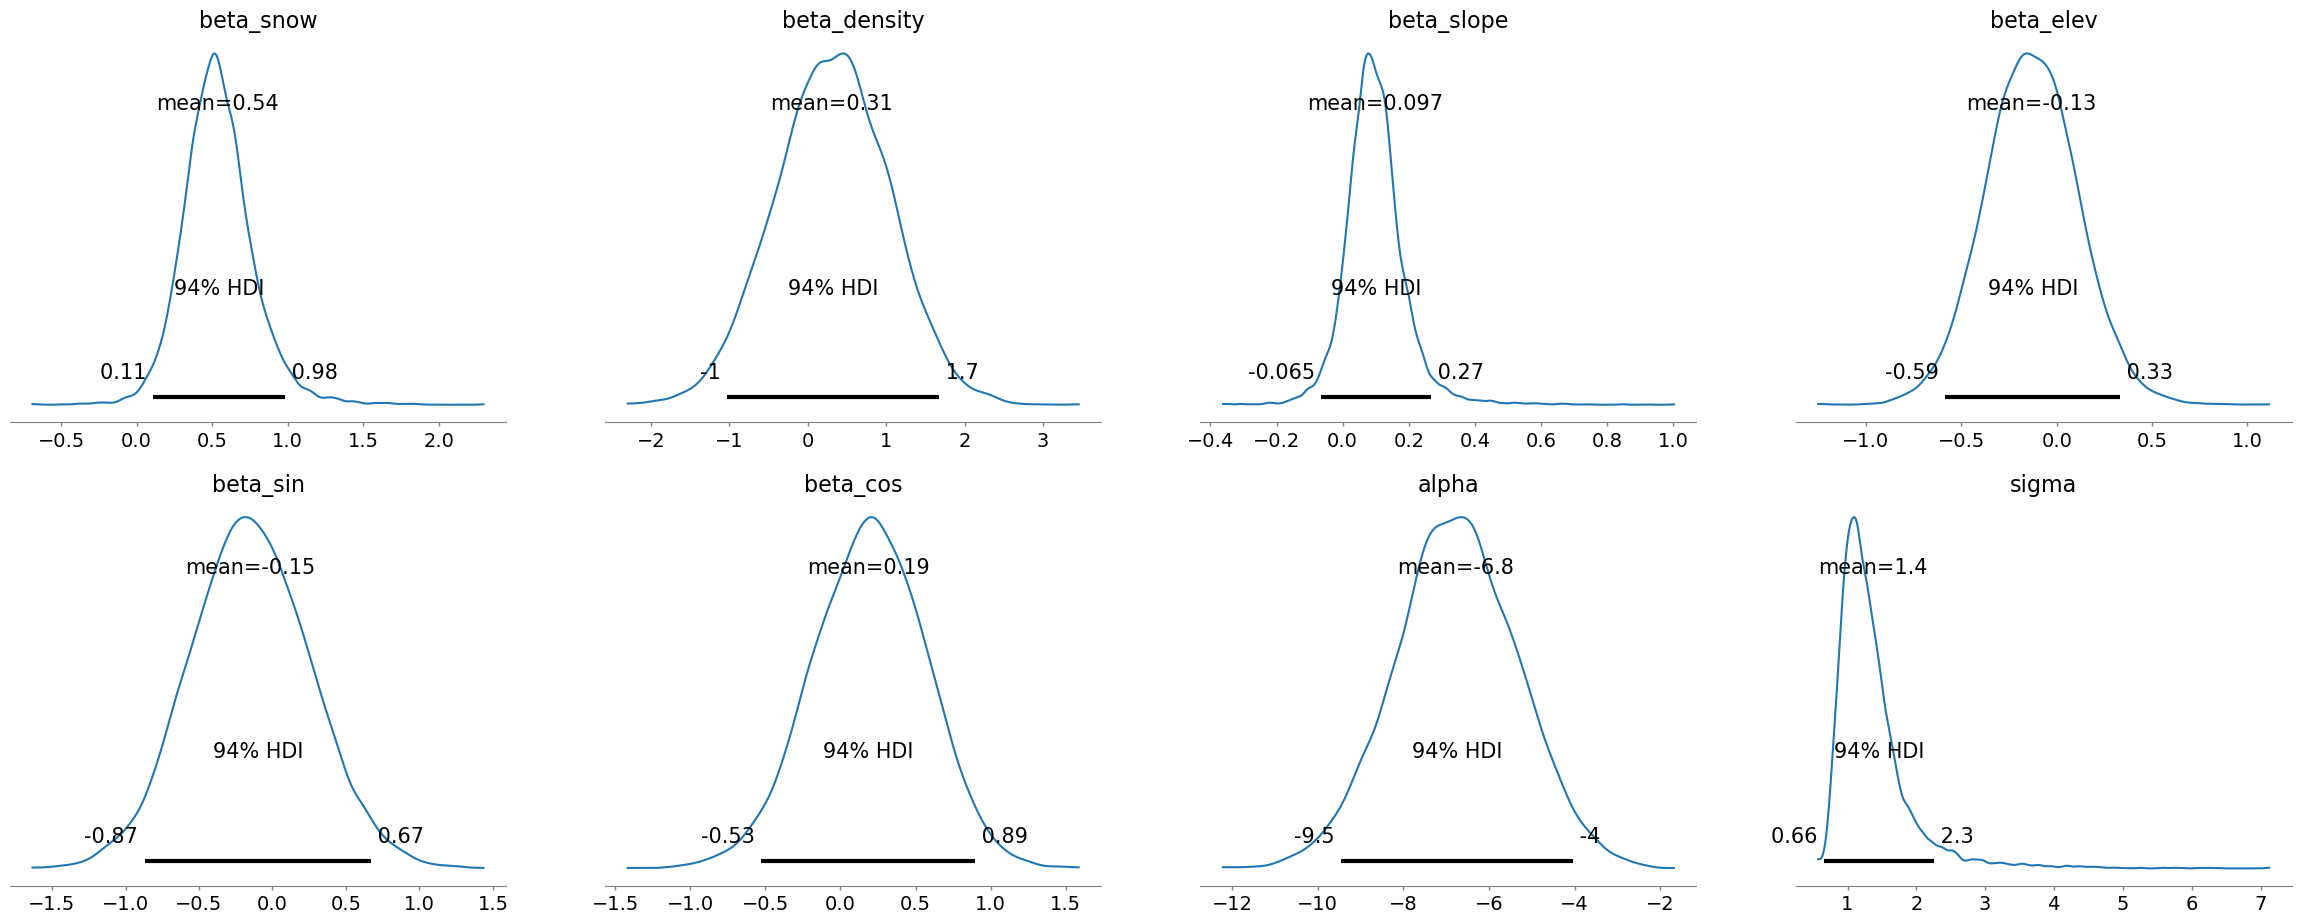

In [93]:
plot_all_posterior_coefficients(model_depth_density_topography_idata)

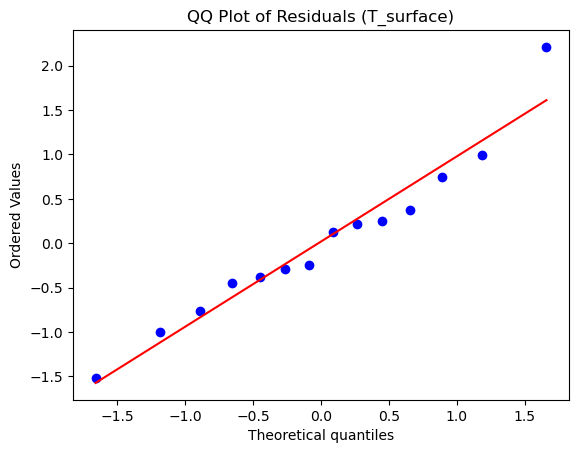

In [94]:
residuals = plot_residual_qq(
    model_depth_density_topography_idata,
    T_surface,
    var_name="T_surface"
)

In [95]:
r2_table = compute_bayesian_r2(
    model_depth_density_topography_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.537695,0.102137


In [96]:
loo_depth_density_topography = compute_loo(model_depth_density_topography_idata)
print(loo_depth_density_topography)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -24.68     2.61
p_loo        4.51        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       12   85.7%
   (0.70, 1]   (bad)         2   14.3%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

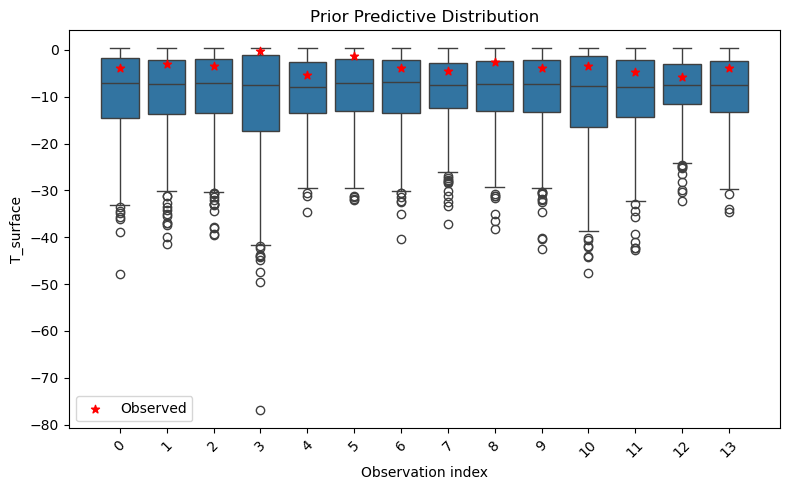

In [97]:
plot_prior_predictions(model_depth_density_topography_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

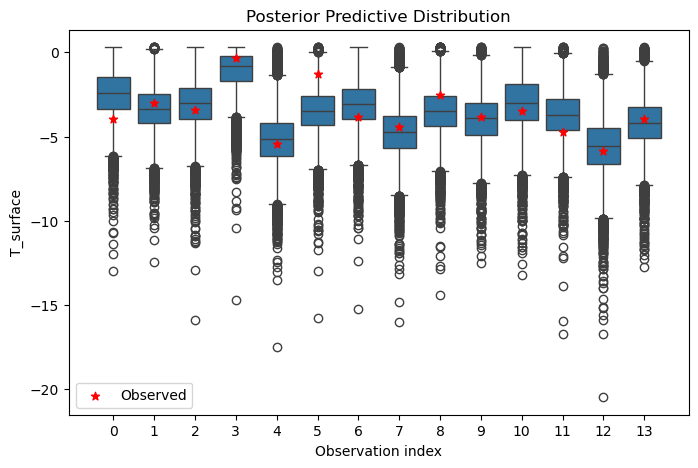

In [98]:
plot_predictions(model_depth_density_topography_idata)

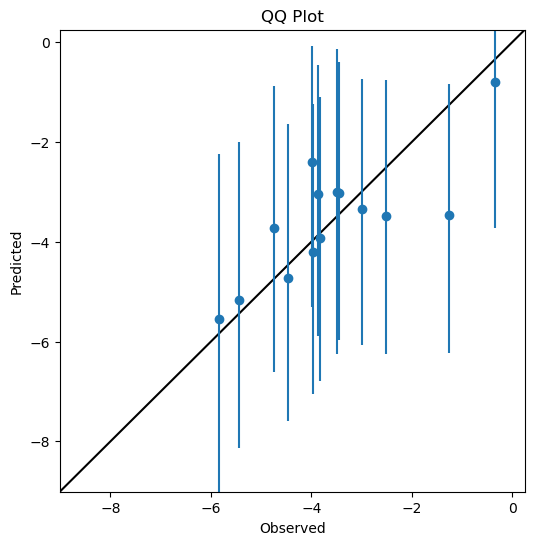

In [99]:
qqplot(model_depth_density_topography_idata)

In [100]:
models = {
    "depth": model_depth_idata,
    "density": model_density_idata,
    "depth_density": model_depth_density_idata,
    "depth_topography": model_depth_topography_idata,
    "density_topography": model_density_topography_idata,
    "depth_density_topography": model_depth_density_topography_idata,
    "topography": model_topography_idata
}



In [101]:
comparison_results = []

for name, idata in models.items():
    
    # R²
    r2 = compute_bayesian_r2(idata, T_surface)
    r2_mean = float(r2["R2_mean"].values[0])
    r2_sd   = float(r2["R2_sd"].values[0])
    
    # LOO
    loo = compute_loo(idata)
    
    comparison_results.append({
        "Model": name,
        "R2_mean": r2_mean,
        "R2_sd": r2_sd,
        "elpd_loo": loo.elpd_loo,
        "p_loo": loo.p_loo,
        "loo_se": loo.se
    })

comparison_table = pd.DataFrame(comparison_results)


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur0

In [102]:
print(comparison_table)

                      Model   R2_mean     R2_sd   elpd_loo     p_loo    loo_se
0                     depth  0.498235  0.105141 -23.066480  2.763438  2.773843
1                   density  0.355737  0.090430 -27.016472  2.171559  2.453006
2             depth_density  0.491655  0.110355 -23.569156  3.114001  2.766445
3          depth_topography  0.541396  0.101108 -24.493244  4.340745  2.638633
4        density_topography  0.429329  0.092064 -27.687748  3.879390  1.857985
5  depth_density_topography  0.537695  0.102137 -24.682828  4.514827  2.610725
6                topography  0.426469  0.090642 -28.069561  3.656423  1.681593


In [103]:
comparison_table = comparison_table.sort_values(
    by="elpd_loo",
    ascending=False
)

comparison_table


,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se
0,depth,0.498235,0.105141,-23.066480,2.763438,2.773843
2,depth_density,0.491655,0.110355,-23.569156,3.114001,2.766445
3,depth_topography,0.541396,0.101108,-24.493244,4.340745,2.638633
5,depth_density_topography,0.537695,0.102137,-24.682828,4.514827,2.610725
1,density,0.355737,0.090430,-27.016472,2.171559,2.453006
4,density_topography,0.429329,0.092064,-27.687748,3.879390,1.857985
6,topography,0.426469,0.090642,-28.069561,3.656423,1.681593


In [104]:
best_loo = comparison_table["elpd_loo"].max()

comparison_table["delta_elpd"] = best_loo - comparison_table["elpd_loo"]

comparison_table


,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se,delta_elpd
0,depth,0.498235,0.105141,-23.066480,2.763438,2.773843,0.000000
2,depth_density,0.491655,0.110355,-23.569156,3.114001,2.766445,0.502676
3,depth_topography,0.541396,0.101108,-24.493244,4.340745,2.638633,1.426764
5,depth_density_topography,0.537695,0.102137,-24.682828,4.514827,2.610725,1.616348
1,density,0.355737,0.090430,-27.016472,2.171559,2.453006,3.949992
4,density_topography,0.429329,0.092064,-27.687748,3.879390,1.857985,4.621268
6,topography,0.426469,0.090642,-28.069561,3.656423,1.681593,5.003081


# Sensitivity Analysis

## Uninformed priors for best model (model_depth)

To assess the sensitivity of model results to prior specification, we evaluated models with Normal priors of standard deviation ($sigma=10$) for the predictors, while keeping the likelihood and model structure unchanged. In weakly informed models parameter uncertainty increased, with snow density in particular showing wide credible intervals spanning physically implausible values. Thus, informed prior specification provides more conservative and physically plausible estimates, motivating the use of the informed prior model as the primary analytical framework in this study.

In [105]:
T_surface = df["T_surface"].values

with pm.Model() as model_uninformed:

    # Data
    snow = pm.Data("snow", df["snow_10cm"].values)

    # Intercept (physically constrained)
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-7.1,          
        sigma=10,      
        upper=0.3
    )

    # Snow slope 
    beta_snow = pm.Normal(
        "beta_snow",
        mu=0,
        sigma=10        
    )

    # Linear predictor
    mu = alpha + beta_snow * snow

    # Residual variance
    sigma = pm.HalfNormal(
        "sigma",
        sigma=10        
    )

    # Likelihood
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [106]:
model_uninformed_prior, model_uninformed_idata = run_model(model_uninformed)

Sampling: [T_surface, alpha, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 76 seconds.
There were 1440 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

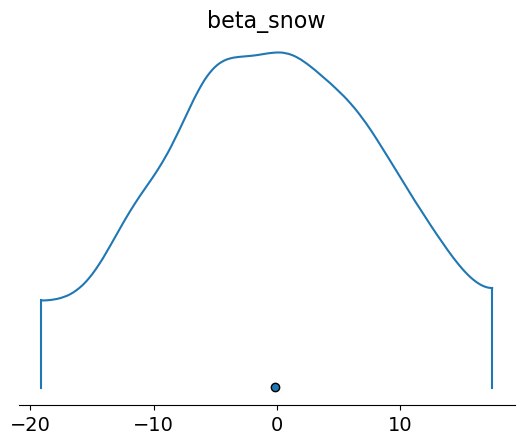

In [107]:
plot_all_prior_coefficients(model_uninformed_prior)

In [108]:
prior_summary = summarize_all_prior_coefficients(model_uninformed_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,7.90,6.33,0.06,19.42,0.18,0.18,1208.77,1025.21,NaN
alpha,-11.31,7.64,-24.72,0.19,0.24,0.18,1020.34,1025.75,NaN
beta_snow,-0.15,9.81,-19.16,17.52,0.33,0.21,899.80,759.67,NaN


In [109]:
summary = summarize_all_posterior_coefficients(model_uninformed_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,0.64,0.32,0.23,1.09,0.02,0.04,72.27,278.05,1.05
alpha,-7.12,1.40,-9.90,-4.96,0.19,0.04,45.41,873.48,1.07
sigma,1.36,0.64,0.74,2.07,0.02,0.09,667.80,1290.33,1.06


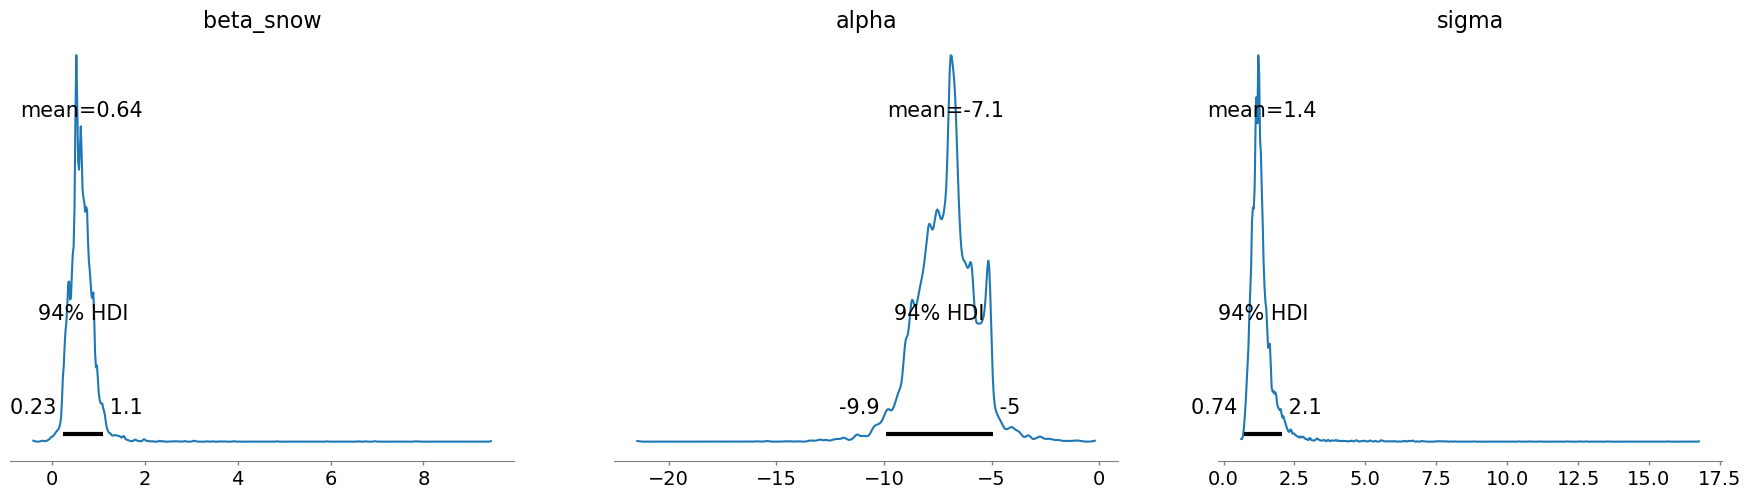

In [110]:
plot_all_posterior_coefficients(model_uninformed_idata)

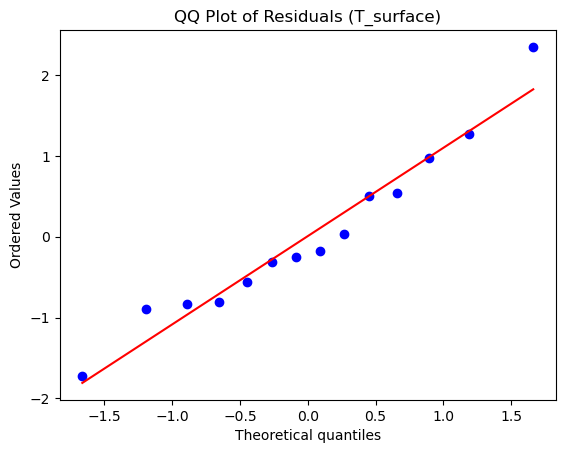

In [111]:
residuals = plot_residual_qq(
    model_uninformed_idata,
    T_surface,
    var_name="T_surface"
)

In [112]:
r2_table = compute_bayesian_r2(
    model_uninformed_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.496531,0.110098


In [113]:
loo_uninformed = compute_loo(model_uninformed_idata)
print(loo_uninformed)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -23.70     2.47
p_loo        2.99        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13   92.9%
   (0.70, 1]   (bad)         1    7.1%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:1042: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

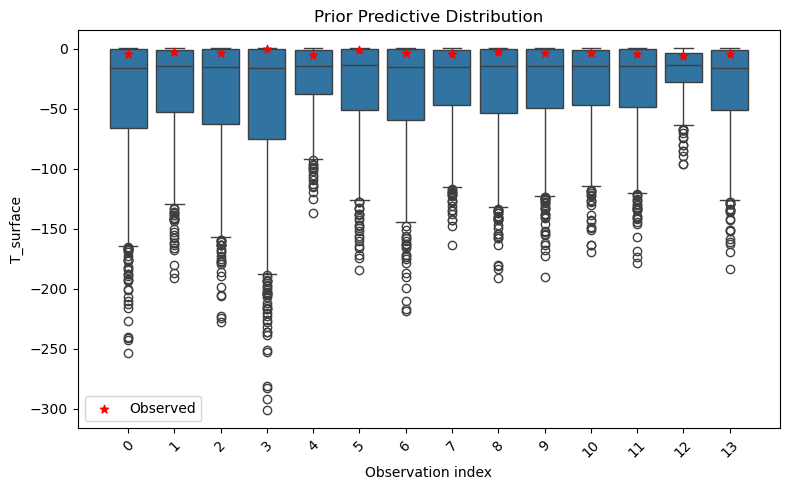

In [114]:
plot_prior_predictions(model_uninformed_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

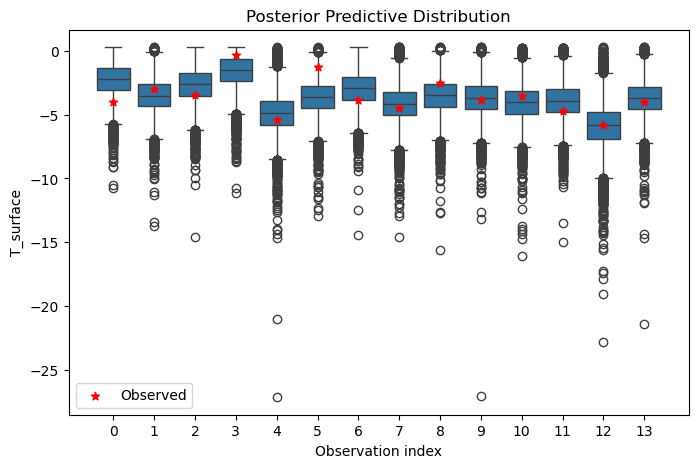

In [115]:
plot_predictions(model_uninformed_idata)

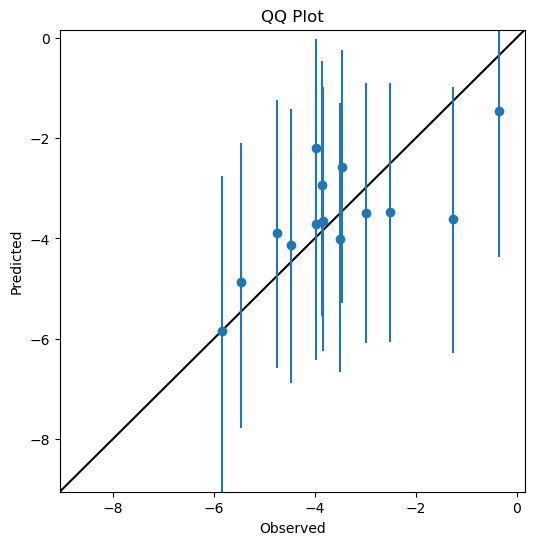

In [116]:
qqplot(model_uninformed_idata)

## Analytical Model

As a sensitivity analysis, we fitted an analytical Bayesian linear regression with conjugate priors to examine the relationship between snow depth and surface temperature. In this formulation, surface temperature was modeled as a linear function of snow depth under the assumption of Gaussian residual errors. 

The reduced predictive skill of the analytical approach likely reflects its stronger structural assumptions and limited flexibility compared to the numerically sampled MCMC framework. These results support the use of the MCMC-based models (above) as the primary analytical approach in this study.

In [117]:
y = df["T_surface"].values  # target variable
X = df[["snow_10cm"]].values  # predictors
n = len(y)

# Add intercept column
X = np.column_stack([np.ones(n), X])

# Priors: beta ~ N(mu_prior, sigma_prior^2)
mu_prior = np.array([-7.1, 0])   # intercept, snow_depth, bulk_density
sigma_prior = np.array([2.0, 2.0])
Lambda_prior = np.diag(1 / sigma_prior**2)  # precision matrix of prior


In [118]:
sigma = 2.0
sigma2 = sigma**2

In [119]:
# Posterior covariance
Sigma_post = np.linalg.inv((X.T @ X) / sigma2 + Lambda_prior)

# Posterior mean
mu_post = Sigma_post @ ((X.T @ y) / sigma2 + Lambda_prior @ mu_prior)

print("Posterior mean:", mu_post)
print("Posterior covariance matrix:\n", Sigma_post)

Posterior mean: [-6.95083202  0.57931542]
Posterior covariance matrix:
 [[ 1.78424213 -0.28068597]
 [-0.28068597  0.05191479]]


In [120]:
samples = np.random.multivariate_normal(mu_post, Sigma_post, size=1000)

In [121]:
# --- 1️⃣ Analytical posterior predictive R² ---

# Sample beta from analytical posterior
n_draws = 1000
beta_samples = np.random.multivariate_normal(mu_post, Sigma_post, size=n_draws)

# Compute R² for each draw
r2_analytical = np.zeros(n_draws)
y_true = y  # observed T_surface
y_mean = np.mean(y_true)

for i in range(n_draws):
    y_pred = X @ beta_samples[i]  # predicted T_surface for this beta sample
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_mean)**2)
    r2_analytical[i] = 1 - ss_res / ss_tot

# Summarize
r2_analytical_mean = np.mean(r2_analytical)
r2_analytical_sd = np.std(r2_analytical)
r2_analytical_ci = np.percentile(r2_analytical, [2.5, 97.5])

print("Analytical posterior predictive R²:")
print(f"Mean: {r2_analytical_mean:.3f}, SD: {r2_analytical_sd:.3f}, 95% CI: [{r2_analytical_ci[0]:.3f}, {r2_analytical_ci[1]:.3f}]")


Analytical posterior predictive R²:
Mean: 0.290, SD: 0.230, 95% CI: [-0.361, 0.510]


## Vegetation influence 
(model_depth) grouped by vegetation 

In [186]:
veg_codes, veg_idx = np.unique(df["vegetation"], return_inverse=True)
n_veg = len(veg_codes)

In [188]:
veg_codes

array(['dry shrub', 'dry tundra', 'moist shrub', 'moist tundra'],
      dtype=object)

0 = dry shrub
1 = dry tundra
2 = moist shrub
3 = moist tundra

In [123]:
T_surface = df["T_surface"].values

with pm.Model() as model_veg:

    # Data
    snow = pm.Data("snow", df["snow_10cm"].values)
    veg = pm.Data("veg", veg_idx)

    # Global intercept
    alpha_mu = pm.TruncatedNormal("alpha_mu", mu=-7.1, sigma=1.5, upper=0.3)

    # Between-vegetation variability
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1)

    # Vegetation-specific intercepts
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=alpha_mu,
        sigma=sigma_alpha,
        upper=0.3,
        shape=n_veg
    )

    # Snow slope (pooled)
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,        
        sigma=1
    )

    # Linear predictor
    mu = alpha[veg] + beta_snow * snow

    # Residual
    sigma = pm.HalfNormal("sigma", sigma=4)

    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )

In [124]:
model_veg_prior,model_veg_idata = run_model(model_veg)

Sampling: [T_surface, alpha, alpha_mu, beta_snow, sigma, sigma_alpha]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_mu, sigma_alpha, alpha, beta_snow, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 107 seconds.
There were 933 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

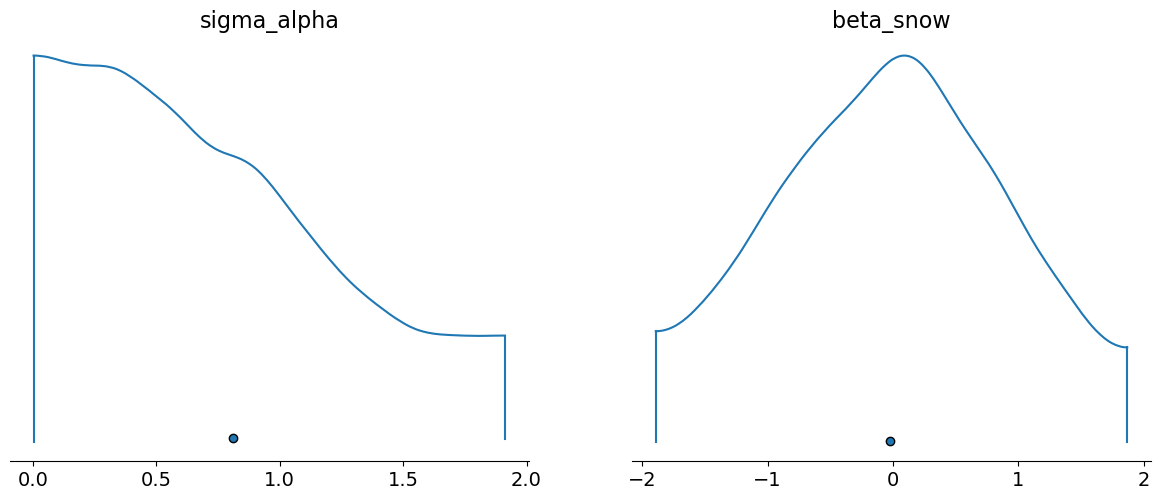

In [125]:
plot_all_prior_coefficients(model_veg_prior)

In [126]:
prior_summary = summarize_all_prior_coefficients(model_veg_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_alpha,0.81,0.62,0.00,1.91,0.02,0.02,1059.90,881.39,NaN
alpha[0],-7.15,1.79,-10.53,-3.81,0.05,0.04,1104.77,975.63,NaN
alpha[1],-7.20,1.81,-10.43,-3.77,0.06,0.05,1023.51,849.83,NaN
alpha[2],-7.17,1.79,-10.54,-3.89,0.06,0.05,1020.48,983.28,NaN
alpha[3],-7.14,1.83,-10.68,-3.90,0.05,0.04,1125.76,1013.72,NaN
sigma,3.40,2.46,0.01,7.87,0.08,0.06,795.78,746.33,NaN
beta_snow,-0.02,1.01,-1.90,1.87,0.03,0.02,1095.19,850.21,NaN


In [127]:
summary = summarize_all_posterior_coefficients(model_veg_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,0.59,0.16,0.28,0.89,0.00,0.00,1627.46,1706.28,1.02
sigma_alpha,0.54,0.39,0.05,1.25,0.02,0.01,136.15,147.67,1.04
alpha[0],-6.73,0.99,-8.61,-4.80,0.02,0.02,1624.85,1784.36,1.01
alpha[1],-7.22,0.95,-9.11,-5.44,0.02,0.02,1628.08,1672.66,1.02
alpha[2],-6.91,0.95,-8.75,-5.11,0.02,0.02,1657.37,1789.37,1.01
alpha[3],-6.87,0.95,-8.75,-5.09,0.02,0.02,1624.88,1823.73,1.01
sigma,1.22,0.35,0.69,1.80,0.01,0.01,1208.13,3272.53,1.01


0 = dry shrub
1 = dry tundra
2 = moist shrub
3 = moist tundra

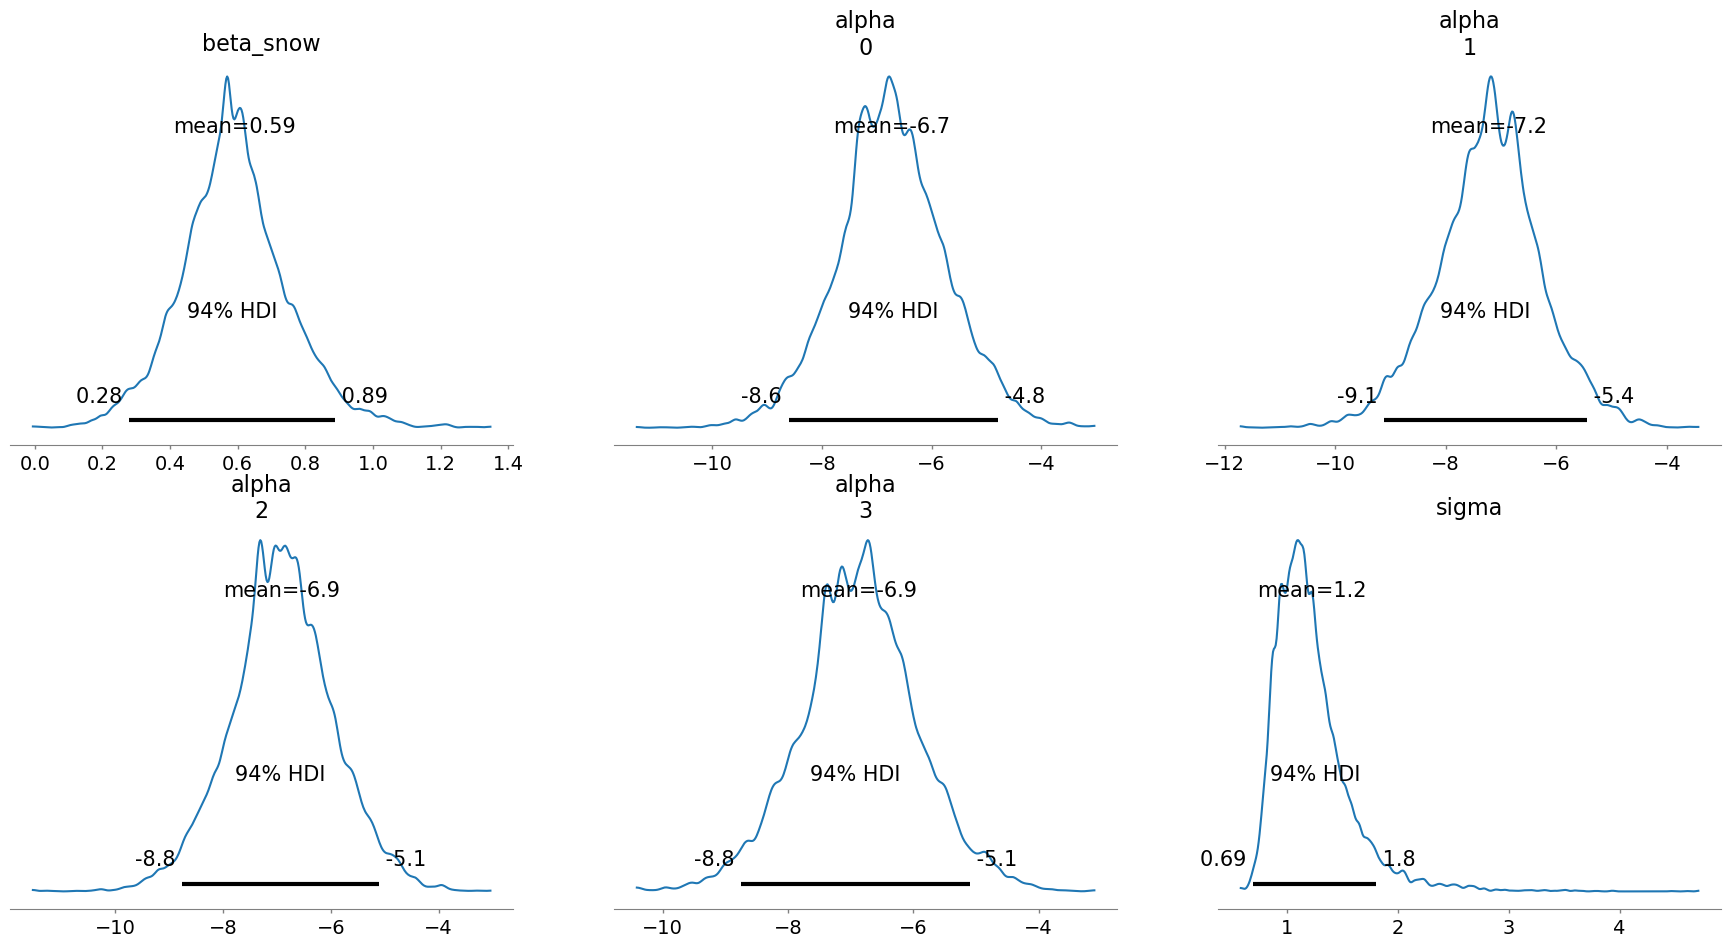

In [128]:
plot_all_posterior_coefficients(model_veg_idata)

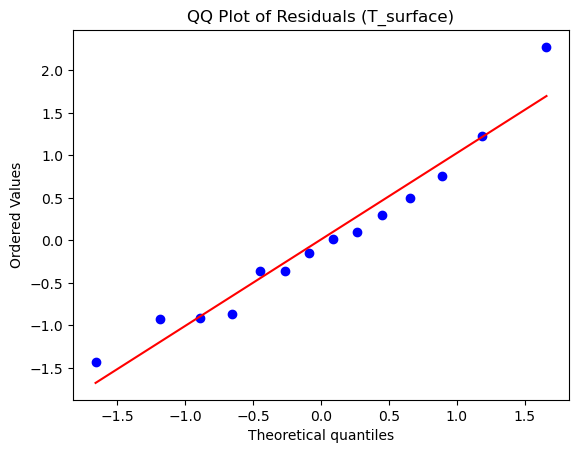

In [129]:
residuals = plot_residual_qq(
    model_veg_idata,
    T_surface,
    var_name="T_surface"
)

In [130]:
r2_table = compute_bayesian_r2(
    model_veg_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.512738,0.10667


In [131]:
loo_veg = compute_loo(model_veg_idata)
print(loo_veg)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -23.35     2.74
p_loo        3.47        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       14  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

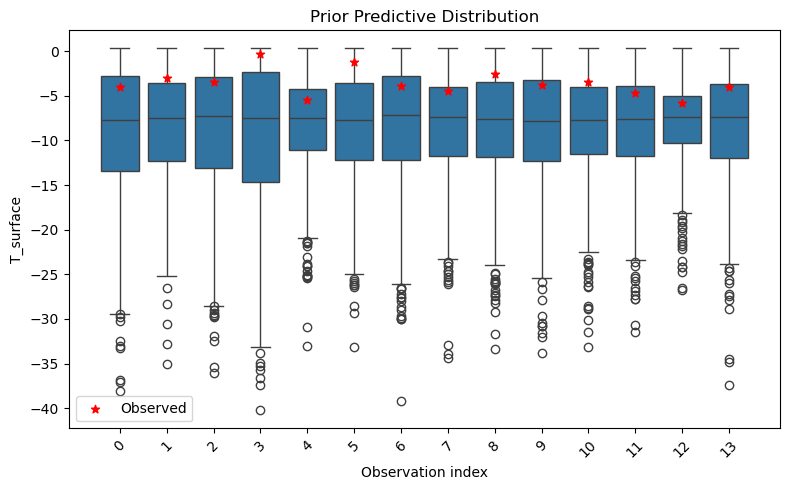

In [132]:
plot_prior_predictions(model_veg_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

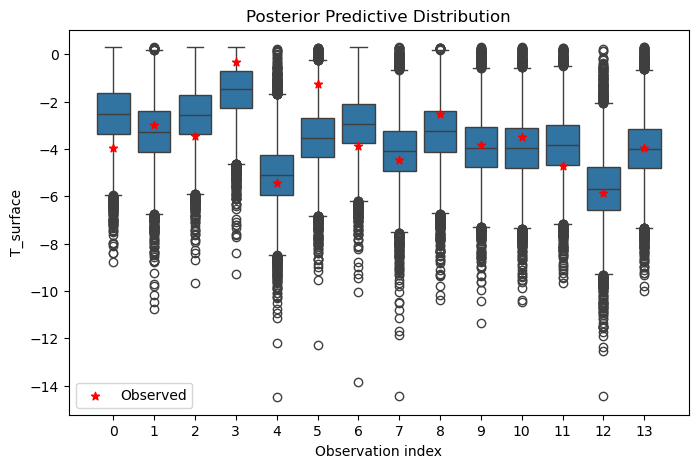

In [133]:
plot_predictions(model_veg_idata)

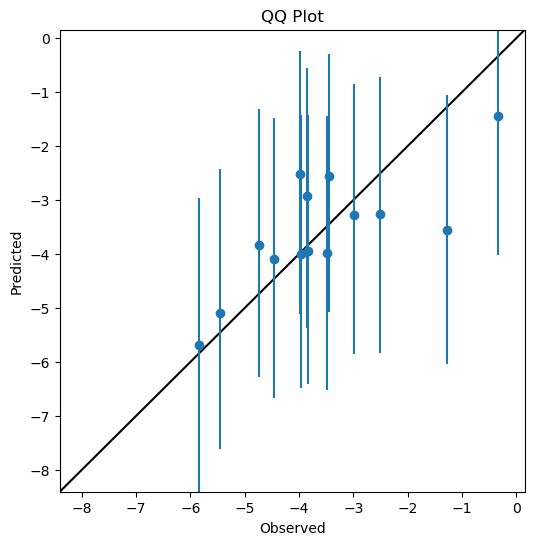

In [134]:
qqplot(model_veg_idata)

# Model comparison 

In [135]:
models = {
    "depth": model_depth_idata,
    "density": model_density_idata,
    "depth_density": model_depth_density_idata,
    "depth_topography": model_depth_topography_idata,
    "density_topography": model_density_topography_idata,
    "depth_density_topography": model_depth_density_topography_idata,
    "topography": model_topography_idata, 
    "depth_uninformed": model_uninformed_idata,
    "depth_vegetation": model_veg_idata
}



In [136]:
comparison_results = []

for name, idata in models.items():
    
    # R²
    r2 = compute_bayesian_r2(idata, T_surface)
    r2_mean = float(r2["R2_mean"].values[0])
    r2_sd   = float(r2["R2_sd"].values[0])
    
    # LOO
    loo = compute_loo(idata)
    
    comparison_results.append({
        "Model": name,
        "R2_mean": r2_mean,
        "R2_sd": r2_sd,
        "elpd_loo": loo.elpd_loo,
        "p_loo": loo.p_loo,
        "loo_se": loo.se
    })

comparison_table = pd.DataFrame(comparison_results)


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur0

In [137]:
comparison_table = comparison_table.sort_values(
    by="elpd_loo",
    ascending=False
)

comparison_table

,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se
0,depth,0.498235,0.105141,-23.066480,2.763438,2.773843
8,depth_vegetation,0.512738,0.106670,-23.352695,3.473226,2.742898
2,depth_density,0.491655,0.110355,-23.569156,3.114001,2.766445
7,depth_uninformed,0.496531,0.110098,-23.704715,2.987206,2.472910
3,depth_topography,0.541396,0.101108,-24.493244,4.340745,2.638633
5,depth_density_topography,0.537695,0.102137,-24.682828,4.514827,2.610725
1,density,0.355737,0.090430,-27.016472,2.171559,2.453006
4,density_topography,0.429329,0.092064,-27.687748,3.879390,1.857985
6,topography,0.426469,0.090642,-28.069561,3.656423,1.681593


In [138]:
best_loo = comparison_table["elpd_loo"].max()

comparison_table["delta_elpd"] = best_loo - comparison_table["elpd_loo"]

comparison_table


,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se,delta_elpd
0,depth,0.498235,0.105141,-23.066480,2.763438,2.773843,0.000000
8,depth_vegetation,0.512738,0.106670,-23.352695,3.473226,2.742898,0.286215
2,depth_density,0.491655,0.110355,-23.569156,3.114001,2.766445,0.502676
7,depth_uninformed,0.496531,0.110098,-23.704715,2.987206,2.472910,0.638235
3,depth_topography,0.541396,0.101108,-24.493244,4.340745,2.638633,1.426764
5,depth_density_topography,0.537695,0.102137,-24.682828,4.514827,2.610725,1.616348
1,density,0.355737,0.090430,-27.016472,2.171559,2.453006,3.949992
4,density_topography,0.429329,0.092064,-27.687748,3.879390,1.857985,4.621268
6,topography,0.426469,0.090642,-28.069561,3.656423,1.681593,5.003081


In [139]:
comparison_results = []

for name, idata in models.items():
    
    # R²
    r2 = compute_bayesian_r2(idata, T_surface)
    r2_mean = float(r2["R2_mean"].values[0])
    r2_sd   = float(r2["R2_sd"].values[0])
    
    # LOO
    loo = az.loo(idata)
    
    # WAIC
    waic = az.waic(idata)
    
    comparison_results.append({
        "Model": name,
        "R2_mean": r2_mean,
        "R2_sd": r2_sd,
        "elpd_loo": loo.elpd_loo,
        "p_loo": loo.p_loo,
        "loo_se": loo.se,
        "elpd_waic": waic.elpd_waic,
        "p_waic": waic.p_waic,
        "waic_se": waic.se
    })

comparison_table = pd.DataFrame(comparison_results)


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
c:\Users\sobaur001\AppData\L

In [140]:
comparison_table

,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se,elpd_waic,p_waic,waic_se
0,depth,0.498235,0.105141,-23.066480,2.763438,2.773843,-22.873848,2.570806,2.661756
1,density,0.355737,0.090430,-27.016472,2.171559,2.453006,-26.905963,2.061050,2.391017
2,depth_density,0.491655,0.110355,-23.569156,3.114001,2.766445,-23.308907,2.853752,2.614977
3,depth_topography,0.541396,0.101108,-24.493244,4.340745,2.638633,-23.932026,3.779527,2.423833
4,density_topography,0.429329,0.092064,-27.687748,3.879390,1.857985,-27.286053,3.477696,1.710084
5,depth_density_topography,0.537695,0.102137,-24.682828,4.514827,2.610725,-24.068890,3.900889,2.387376
6,topography,0.426469,0.090642,-28.069561,3.656423,1.681593,-27.626314,3.213177,1.525602
7,depth_uninformed,0.496531,0.110098,-23.704715,2.987206,2.472910,-23.448161,2.730653,2.340641
8,depth_vegetation,0.512738,0.106670,-23.352695,3.473226,2.742898,-23.081858,3.202388,2.597416


In [141]:
comparison = az.compare(models, ic="loo")

comparison


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur0

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
depth,0,-23.066480,2.763438,0.000000,9.580072e-01,2.773843,0.000000,False,log
depth_vegetation,1,-23.352695,3.473226,0.286215,2.342680e-15,2.742898,0.392810,False,log
depth_density,2,-23.569156,3.114001,0.502676,1.054870e-16,2.766445,0.199562,False,log
depth_uninformed,3,-23.704715,2.987206,0.638235,1.048971e-15,2.472910,0.377432,True,log
depth_topography,4,-24.493244,4.340745,1.426764,6.677764e-16,2.638633,1.000013,True,log
depth_density_topography,5,-24.682828,4.514827,1.616348,5.376395e-16,2.610725,1.025018,True,log
density,6,-27.016472,2.171559,3.949992,4.199282e-02,2.453006,2.984347,False,log
density_topography,7,-27.687748,3.879390,4.621268,1.995303e-17,1.857985,2.815367,False,log
topography,8,-28.069561,3.656423,5.003081,0.000000e+00,1.681593,2.646064,True,log


In [142]:
for name, idata in models.items():
    loo = az.loo(idata)
    k_vals = loo.pareto_k.values
    
    print(f"\nModel: {name}")
    print("Max k:", np.max(k_vals))
    print("k > 0.7:", np.sum(k_vals > 0.7))
    print("k > 1.0:", np.sum(k_vals > 1.0))



Model: depth
Max k: 0.6557856104716733
k > 0.7: 0
k > 1.0: 0

Model: density
Max k: 0.5989576106961938
k > 0.7: 0
k > 1.0: 0

Model: depth_density
Max k: 0.6653930411521858
k > 0.7: 0
k > 1.0: 0

Model: depth_topography
Max k: 0.7696980209236735
k > 0.7: 1
k > 1.0: 0


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur0


Model: density_topography
Max k: 0.5664065574249159
k > 0.7: 0
k > 1.0: 0

Model: depth_density_topography
Max k: 0.7178122539917076
k > 0.7: 2
k > 1.0: 0

Model: topography
Max k: 0.8095228783749474
k > 0.7: 1
k > 1.0: 0

Model: depth_uninformed
Max k: 0.711183204377997
k > 0.7: 1
k > 1.0: 0

Model: depth_vegetation
Max k: 0.6378523611133317
k > 0.7: 0
k > 1.0: 0


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:1042: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [143]:
loo_depth_topo = az.loo(model_depth_density_topography_idata)

k_vals = loo_depth_topo.pareto_k.values

# Indices where k > 0.7
influential_idx = np.where(k_vals > 0.7)[0]

print("Influential observation indices:", influential_idx)
print("Corresponding k values:", k_vals[influential_idx])


Influential observation indices: [0 5]
Corresponding k values: [0.70551361 0.71781225]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [144]:
influential_data = df.iloc[influential_idx][
    ["T_surface", "snow_10cm", "density_01", "slope", "aspect", "elevation"]
]

influential_data

,T_surface,snow_10cm,density_01,slope,aspect,elevation
0,-3.98,8.1,3.07,2.66,6.63,88.0
5,-1.27,5.7,2.89,3.27,320.75,86.5


In [145]:
df[["snow_10cm", "density_01", "slope", "aspect", "elevation"]].describe()

,snow_10cm,density_01,slope,aspect,elevation
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,5.792857,2.985714,5.132857,212.682143,95.155714
std,1.854916,0.187687,6.037477,103.126962,10.033412
min,2.000000,2.720000,0.350000,4.350000,83.810000
25%,5.050000,2.882500,2.147500,161.362500,88.027500
50%,5.650000,2.935000,2.705000,256.815000,90.435000
75%,6.575000,3.035000,4.737500,282.475000,104.862500
max,9.600000,3.430000,19.580000,320.750000,110.740000


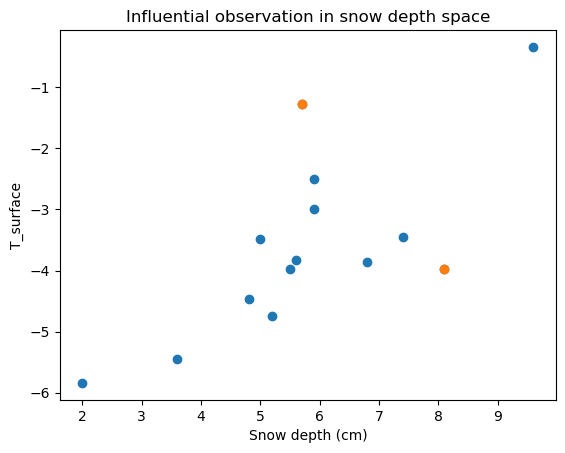

In [146]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["snow_10cm"], df["T_surface"])
plt.scatter(
    df.iloc[influential_idx]["snow_10cm"],
    df.iloc[influential_idx]["T_surface"]
)
plt.xlabel("Snow depth (cm)")
plt.ylabel("T_surface")
plt.title("Influential observation in snow depth space")
plt.show()


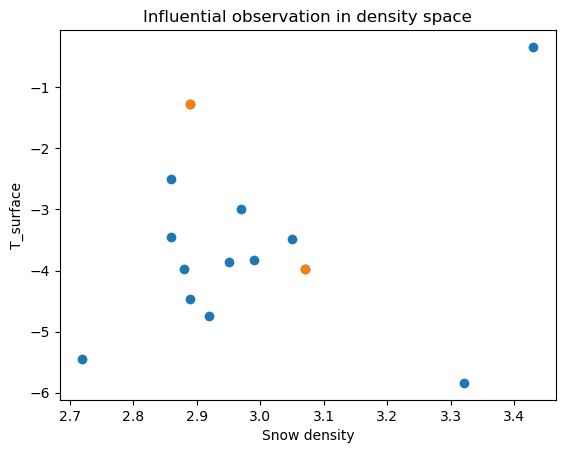

In [147]:
plt.figure()
plt.scatter(df["density_01"], df["T_surface"])
plt.scatter(
    df.iloc[influential_idx]["density_01"],
    df.iloc[influential_idx]["T_surface"]
)
plt.xlabel("Snow density")
plt.ylabel("T_surface")
plt.title("Influential observation in density space")
plt.show()


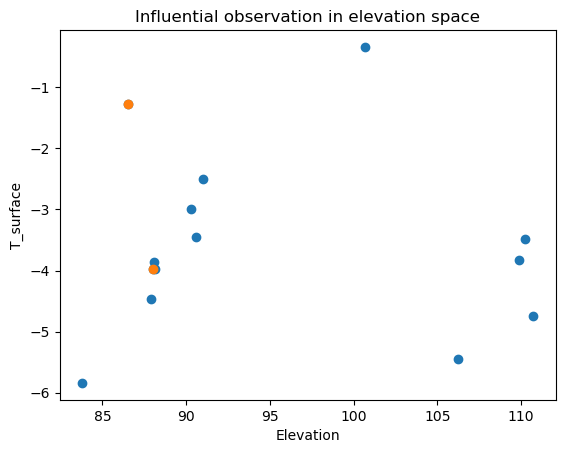

In [148]:
plt.figure()
plt.scatter(df["elevation"], df["T_surface"])
plt.scatter(
    df.iloc[influential_idx]["elevation"],
    df.iloc[influential_idx]["T_surface"]
)
plt.xlabel("Elevation")
plt.ylabel("T_surface")
plt.title("Influential observation in elevation space")
plt.show()


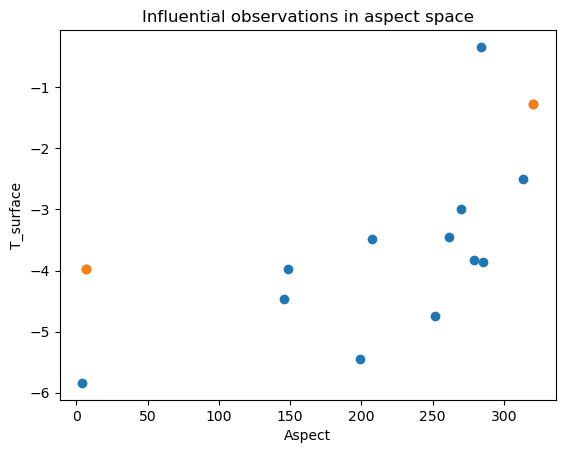

In [149]:
plt.figure()
plt.scatter(df["aspect"], df["T_surface"])
plt.scatter(
    df.loc[[0,5], "aspect"],
    df.loc[[0,5], "T_surface"]
)
plt.xlabel("Aspect")
plt.ylabel("T_surface")
plt.title("Influential observations in aspect space")
plt.show()


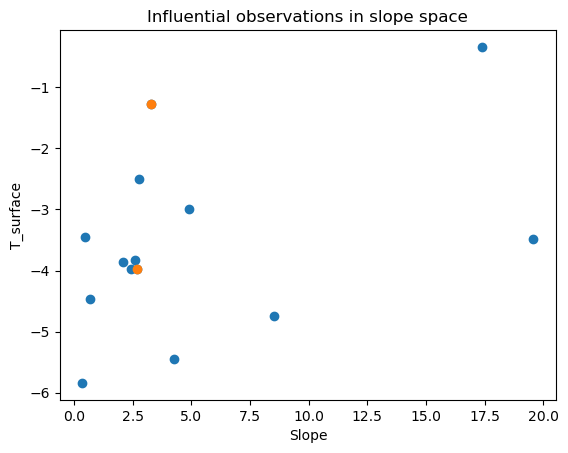

In [150]:
plt.figure()
plt.scatter(df["slope"], df["T_surface"])
plt.scatter(
    df.loc[[0,5], "slope"],
    df.loc[[0,5], "T_surface"]
)
plt.xlabel("Slope")
plt.ylabel("T_surface")
plt.title("Influential observations in slope space")
plt.show()


In [151]:
import numpy as np

# Depth model
depth_pred = model_depth_idata.posterior_predictive["T_surface"].values
depth_pred_mean = depth_pred.mean(axis=(0,1))

# Depth + density model
density_pred = model_density_idata.posterior_predictive["T_surface"].values
density_pred_mean = density_pred.mean(axis=(0,1))

# Full model
full_pred = model_depth_density_topography_idata.posterior_predictive["T_surface"].values
full_pred_mean = full_pred.mean(axis=(0,1))

# Depth + topography model
topo_pred = model_depth_topography_idata.posterior_predictive["T_surface"].values
topo_pred_mean = topo_pred.mean(axis=(0,1))


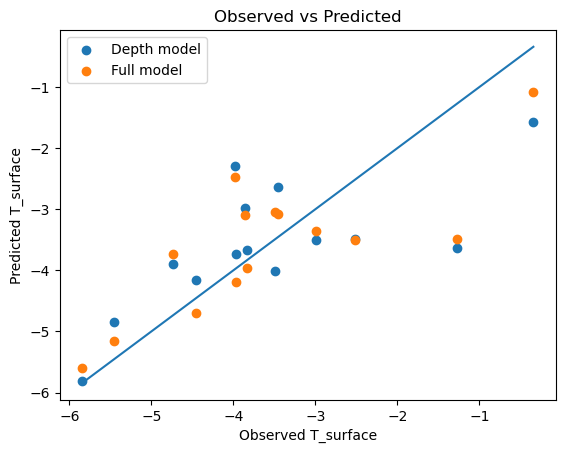

In [152]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(T_surface, depth_pred_mean, label="Depth model")
plt.scatter(T_surface, full_pred_mean, label="Full model")

# 1:1 reference line
lims = [T_surface.min(), T_surface.max()]
plt.plot(lims, lims)

plt.xlabel("Observed T_surface")
plt.ylabel("Predicted T_surface")
plt.legend()
plt.title("Observed vs Predicted")
plt.show()


In [153]:
import arviz as az

comparison = az.compare(
    {
        "Depth": model_depth_idata,
        "Depth+Density": model_density_idata,
        "Full": model_depth_density_topography_idata
    },
    ic="loo"
)

comparison


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Depth,0,-23.066480,2.763438,0.000000,0.957998,2.773843,0.000000,False,log
Full,1,-24.682828,4.514827,1.616348,0.000000,2.610725,1.025018,True,log
Depth+Density,2,-27.016472,2.171559,3.949992,0.042002,2.453006,2.984347,False,log


In [154]:
delta_dd = comparison.loc["Depth+Density", "elpd_diff"]
delta_full = comparison.loc["Full", "elpd_diff"]

se_dd = comparison.loc["Depth+Density", "se"]
se_full = comparison.loc["Full", "se"]


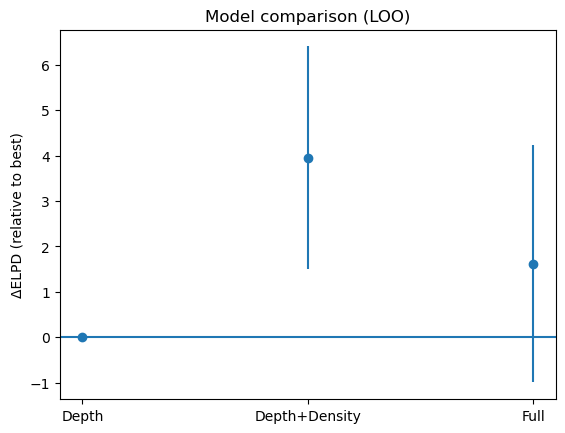

In [155]:
models = ["Depth", "Depth+Density", "Full"]
delta_elpd = [0, delta_dd, delta_full]
se = [0, se_dd, se_full]

plt.figure()
plt.errorbar(models, delta_elpd, yerr=se, fmt='o')
plt.axhline(0)

plt.ylabel("ΔELPD (relative to best)")
plt.title("Model comparison (LOO)")
plt.show()


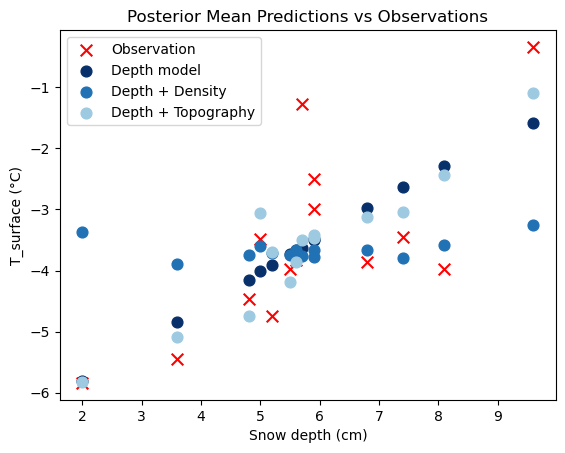

In [156]:
plt.figure()

# Observations (red x markers)
plt.scatter(
    df["snow_10cm"], 
    T_surface,
    marker="x",
    color="red",
    s=70,
    label="Observation"
)

# Depth model (darkest blue)
plt.scatter(
    df["snow_10cm"], 
    depth_pred_mean,
    marker="o",
    color="#08306b",   # darkest blue
    s=60,
    label="Depth model"
)

# Depth + Density (medium blue)
plt.scatter(
    df["snow_10cm"], 
    density_pred_mean,
    marker="o",
    color="#2171b5",   # medium blue
    s=60,
    label="Depth + Density"
)

# Full model (lightest blue)
plt.scatter(
    df["snow_10cm"], 
    topo_pred_mean,
    marker="o",
    color="#9ecae1",   # light blue
    s=60,
    label="Depth + Topography"
)

plt.xlabel("Snow depth (cm)")
plt.ylabel("T_surface (°C)")
plt.legend()
plt.title("Posterior Mean Predictions vs Observations")
plt.show()

In [157]:
import arviz as az
import pandas as pd

summary_full = az.summary(
    model_depth_density_topography_idata,
    var_names=[
        "beta_snow",
        "beta_density",
        "beta_slope",
        "beta_sin",
        "beta_cos",
        "beta_elev"
    ],
    hdi_prob=0.95
)

summary_full


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,0.537,0.236,0.108,1.029,0.003,0.004,7003.0,5205.0,1.0
beta_density,0.308,0.724,-1.123,1.694,0.010,0.006,5616.0,7298.0,1.0
beta_slope,0.097,0.092,-0.076,0.281,0.001,0.003,5779.0,3757.0,1.0
beta_sin,-0.150,0.410,-0.973,0.637,0.004,0.004,9242.0,7886.0,1.0
beta_cos,0.189,0.381,-0.534,0.953,0.004,0.004,9317.0,8420.0,1.0
beta_elev,-0.132,0.245,-0.605,0.349,0.003,0.003,5483.0,6875.0,1.0


In [158]:
summary_full["Predictor"] = [
    "Snow depth",
    "Density",
    "Slope",
    "Aspect_sin",
    "Aspect_cos",
    "Elevation"
]

summary_full = summary_full.reset_index(drop=True)


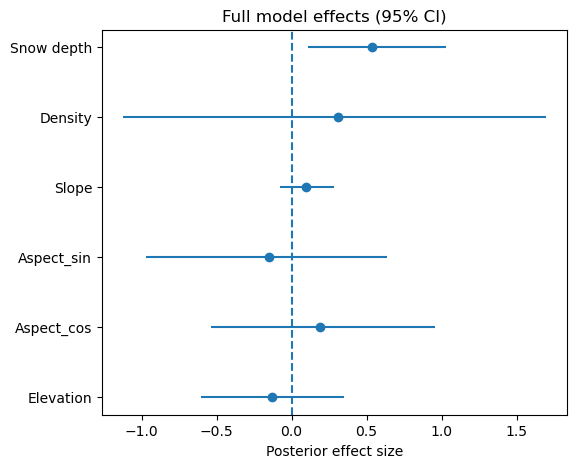

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

y_pos = range(len(summary_full))

# Plot credible intervals
plt.hlines(
    y=y_pos,
    xmin=summary_full["hdi_2.5%"],
    xmax=summary_full["hdi_97.5%"]
)

# Plot posterior means
plt.plot(
    summary_full["mean"],
    y_pos,
    "o"
)

# Zero reference line
plt.axvline(0, linestyle="--")

plt.yticks(y_pos, summary_full["Predictor"])
plt.xlabel("Posterior effect size")
plt.title("Full model effects (95% CI)")

plt.gca().invert_yaxis()
plt.show()


In [160]:
models = {
    "Depth": model_depth_idata,
    "Depth+Density": model_depth_density_idata,
    "Depth+Topo": model_depth_topography_idata,
    "Depth+Density+Topo": model_depth_density_topography_idata,
    "Density": model_density_idata,
    #"Uninformed": model_uninformed_idata
}

predictor_labels = {
    "beta_snow": "Snow depth",
    "beta_density": "Bulk density",
    "beta_slope": "Slope",
    "beta_sin": "Aspect sin",
    "beta_cos": "Aspect cos",
    "beta_elev": "Elevation"
}


In [189]:
rows = []

for model_name, idata in models.items():
    
    summary = az.summary(idata, hdi_prob=0.95)
    
    for param in summary.index:
        
        if param.startswith("beta_"):
            
            rows.append({
                "Model": model_name,
                "Predictor": predictor_labels.get(param, param),
                "Mean": summary.loc[param, "mean"],
                "Lower": summary.loc[param, "hdi_2.5%"],
                "Upper": summary.loc[param, "hdi_97.5%"]
            })

coef_df = pd.DataFrame(rows)

# Save coefficient summary to Downloads
output_file = r"C:\Users\sobaur001\Downloads\coef_df.csv"
coef_df.to_csv(output_file, index=False)



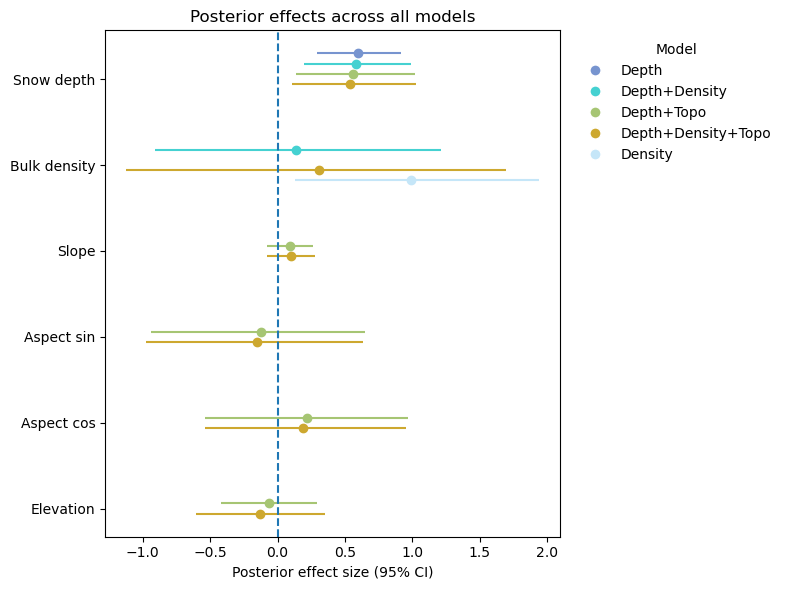

In [162]:
plt.figure(figsize=(8,6))

predictors = list(predictor_labels.values())
y_base = np.arange(len(predictors))

offset = 0.12

models_list = list(models.keys())

colors = {
    "Depth": "#7794cf",
    "Depth+Density": "#45d1d1",
    "Depth+Topo": "#a6c573",
    "Depth+Density+Topo": "#CDA82F",
    "Density": "#c5e6f8",
    #"Uninformed": "#c6dbef"
}

for j, predictor in enumerate(predictors):
    
    y_center = y_base[j]
    
    for i, model_name in enumerate(models_list):
        
        subset = coef_df[
            (coef_df["Model"] == model_name) &
            (coef_df["Predictor"] == predictor)
        ]
        
        if len(subset) == 0:
            continue  # model does not include this predictor
        
        y_pos = y_center + (i - len(models_list)/2) * offset
        
        plt.hlines(
            y=y_pos,
            xmin=subset["Lower"].values[0],
            xmax=subset["Upper"].values[0],
            color=colors[model_name]
        )
        
        plt.plot(
            subset["Mean"].values[0],
            y_pos,
            "o",
            color=colors[model_name]
        )

plt.axvline(0, linestyle="--")
plt.yticks(y_base, predictors)
plt.gca().invert_yaxis()

plt.xlabel("Posterior effect size (95% CI)")
plt.title("Posterior effects across all models")

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[model], markersize=8,
           label=model)
    for model in models_list
]

plt.legend(
    handles=legend_elements,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Model")

plt.tight_layout()
plt.show()

## FIG_5: posterior_effects

Layout for Paper

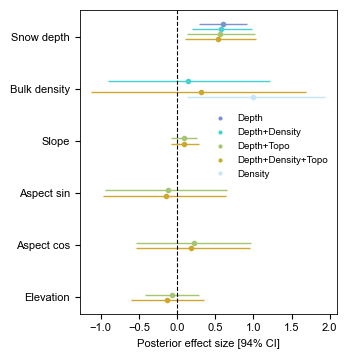

In [163]:
from matplotlib.lines import Line2D

# ------------------------------------------------
# Global journal settings
# ------------------------------------------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6
})

# ------------------------------------------------
# Figure (single column width)
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(3.48, 3.6))

predictors = list(predictor_labels.values())
y_base = np.arange(len(predictors))

offset = 0.10
models_list = list(models.keys())

colors = {
    "Depth": "#7794cf",
    "Depth+Density": "#45d1d1",
    "Depth+Topo": "#a6c573",
    "Depth+Density+Topo": "#CDA82F",
    "Density": "#c5e6f8",
}

# ------------------------------------------------
# Plot posterior intervals
# ------------------------------------------------
for j, predictor in enumerate(predictors):

    y_center = y_base[j]

    for i, model_name in enumerate(models_list):

        subset = coef_df[
            (coef_df["Model"] == model_name) &
            (coef_df["Predictor"] == predictor)
        ]

        if len(subset) == 0:
            continue

        y_pos = y_center + (i - len(models_list)/2) * offset

        ax.hlines(
            y=y_pos,
            xmin=subset["Lower"].values[0],
            xmax=subset["Upper"].values[0],
            color=colors[model_name],
            linewidth=1
        )

        ax.plot(
            subset["Mean"].values[0],
            y_pos,
            "o",
            color=colors[model_name],
            markersize=3
        )

# Zero reference line
ax.axvline(0, linestyle="--", linewidth=0.8, color="black")

# Y axis
ax.set_yticks(y_base)
ax.set_yticklabels(predictors)
ax.invert_yaxis()

# Labels
ax.set_xlabel("Posterior effect size [94% CI]")

# ------------------------------------------------
# Legend
# ------------------------------------------------
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[model],
        markersize=4,
        label=model
    )
    for model in models_list
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    fontsize=7,
    loc="center right",
    bbox_to_anchor=(1, 0.55)
)

plt.tight_layout()

# ------------------------------------------------
# Export
# ------------------------------------------------
plt.savefig("Figure_5_posterior_effects.tiff", dpi=600, bbox_inches="tight")
plt.savefig("Figure_5_posterior_effects.pdf", bbox_inches="tight")

plt.show()

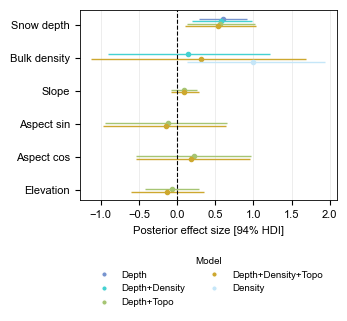

In [164]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ------------------------------------------------
# Global journal settings
# ------------------------------------------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6
})

# ------------------------------------------------
# Figure (shorter height)
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(3.48, 3.4))

predictors = list(predictor_labels.values())

# Compress vertical spacing between predictors
y_base = np.arange(len(predictors)) * 1

offset = 0.08
models_list = list(models.keys())

colors = {
    "Depth": "#7794cf",
    "Depth+Density": "#45d1d1",
    "Depth+Topo": "#a6c573",
    "Depth+Density+Topo": "#CDA82F",
    "Density": "#c5e6f8",
}

# ------------------------------------------------
# Plot posterior intervals
# ------------------------------------------------
for j, predictor in enumerate(predictors):

    y_center = y_base[j]

    for i, model_name in enumerate(models_list):

        subset = coef_df[
            (coef_df["Model"] == model_name) &
            (coef_df["Predictor"] == predictor)
        ]

        if len(subset) == 0:
            continue

        y_pos = y_center + (i - len(models_list)/2) * offset

        ax.hlines(
            y=y_pos,
            xmin=subset["Lower"].values[0],
            xmax=subset["Upper"].values[0],
            color=colors[model_name],
            linewidth=1
        )

        ax.plot(
            subset["Mean"].values[0],
            y_pos,
            "o",
            color=colors[model_name],
            markersize=3
        )

# ------------------------------------------------
# Reference line
# ------------------------------------------------
ax.axvline(0, linestyle="--", linewidth=0.8, color="black")

# ------------------------------------------------
# Grid (vertical only)
# ------------------------------------------------
ax.grid(axis="x", linestyle="-", linewidth=0.4, alpha=0.4)

# ------------------------------------------------
# Y axis
# ------------------------------------------------
ax.set_yticks(y_base)
ax.set_yticklabels(predictors)
ax.invert_yaxis()

# Labels
ax.set_xlabel("Posterior effect size [94% HDI]")

# ------------------------------------------------
# Legend (below plot, two columns)
# ------------------------------------------------
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[model],
        markersize=4,
        label=model
    )
    for model in models_list
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    fontsize=7,
    title="Model",
    title_fontsize=7,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2
)

plt.tight_layout()

# ------------------------------------------------
# Export
# ------------------------------------------------
plt.savefig("Figure_5.tiff", dpi=600, bbox_inches="tight")
plt.savefig("Figure_5.pdf", bbox_inches="tight")

plt.show()

# Review: Add soil moisure to the models 

In [165]:
soil_df = pd.read_csv(
    r"\\dmawi.de\potsdam\data\sparc\personal_accounts\02_Master\2025_Sofia_Bauriedl\01_data\TOMST\tms_smp_averaged_dataset_merged.csv"
)

# ---------------------------------------------------
# Merge soil moisture into main dataframe
# sr_nr (main df) corresponds to tms_id (soil df)
# ---------------------------------------------------

soil_df = soil_df[["tms_id", "soil_moisture"]].copy()

soil_df = soil_df.drop_duplicates(subset="tms_id")

df = df.merge(
    soil_df,
    left_on="sr_nr",
    right_on="tms_id",
    how="left"
)


In [166]:
df.drop(columns=['Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'tms_id'], inplace=True)
df.head()

,tomst_id,sr_nr,TMS_ID,Transect,Plot,Lat,Lon,vegetation,topography,slope,...,T_soil,T_air_1,snow_10cm,density_01,elevation_m,elev_10m,aspect_rad,aspect_sin,aspect_cos,soil_moisture
0,6,94231022.0,A,3.0,1.0,69.278881,-53.479375,dry tundra,footslope,2.66,...,-3.93,-7.09,8.1,3.07,88.00,8.800,0.115715,0.115457,0.993312,0.270004
1,7,94231023.0,B,3.0,2.0,69.278717,-53.477737,dry shrub,footslope,4.90,...,-2.95,-7.09,5.9,2.97,90.29,9.029,4.707677,-0.999989,-0.004712,0.245999
2,8,94231024.0,C,3.0,2.0,69.278723,-53.477548,moist tundra,plain,0.47,...,-3.31,-7.09,7.4,2.86,90.58,9.058,4.566479,-0.989374,-0.145392,0.493143
3,10,94231026.0,D,3.0,3.0,69.278574,-53.474810,moist tundra,hillslope,17.38,...,-0.60,-7.09,9.6,3.43,100.67,10.067,4.951499,-0.971549,0.236838,0.536080
4,15,94231031.0,E,3.0,4.0,69.278654,-53.474111,dry tundra,footslope,4.25,...,-5.90,-7.09,3.6,2.72,106.26,10.626,3.473031,-0.325403,-0.945575,0.230189


In [167]:
df["soil_moist"] = df["soil_moisture"] / 0.1

In [168]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth_density_topography_moisture:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)      
    density = pm.Data("density", df["density_01"].values) 
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)
    soil_moist = pm.Data("soil_moist", df["soil_moist"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-7.1,        # mean air temperature, physically surface = air when snow=0
        sigma=1.5,      # allow some variability
        upper=0.3       # truncate at upper bound of surface temp
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,        
        sigma=1
    )

    beta_density = pm.Normal(
        "beta_density",
        mu=0,         
        sigma=1
    )

    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,         
        sigma=0.5       
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )
    
    beta_soil_moist = pm.Normal(
        "beta_soil_moist",
        mu=0.0, 
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   # observed SD of surface temperature ≈ 2.9°C
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
        + beta_density * density
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
        + beta_soil_moist * soil_moist
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [169]:
model_depth_density_topography_moisture_prior, model_depth_density_topography_moisture_idata = run_model(model_depth_density_topography_moisture)

Sampling: [T_surface, alpha, beta_cos, beta_density, beta_elev, beta_sin, beta_slope, beta_snow, beta_soil_moist, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, beta_density, beta_slope, beta_elev, beta_sin, beta_cos, beta_soil_moist, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 144 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

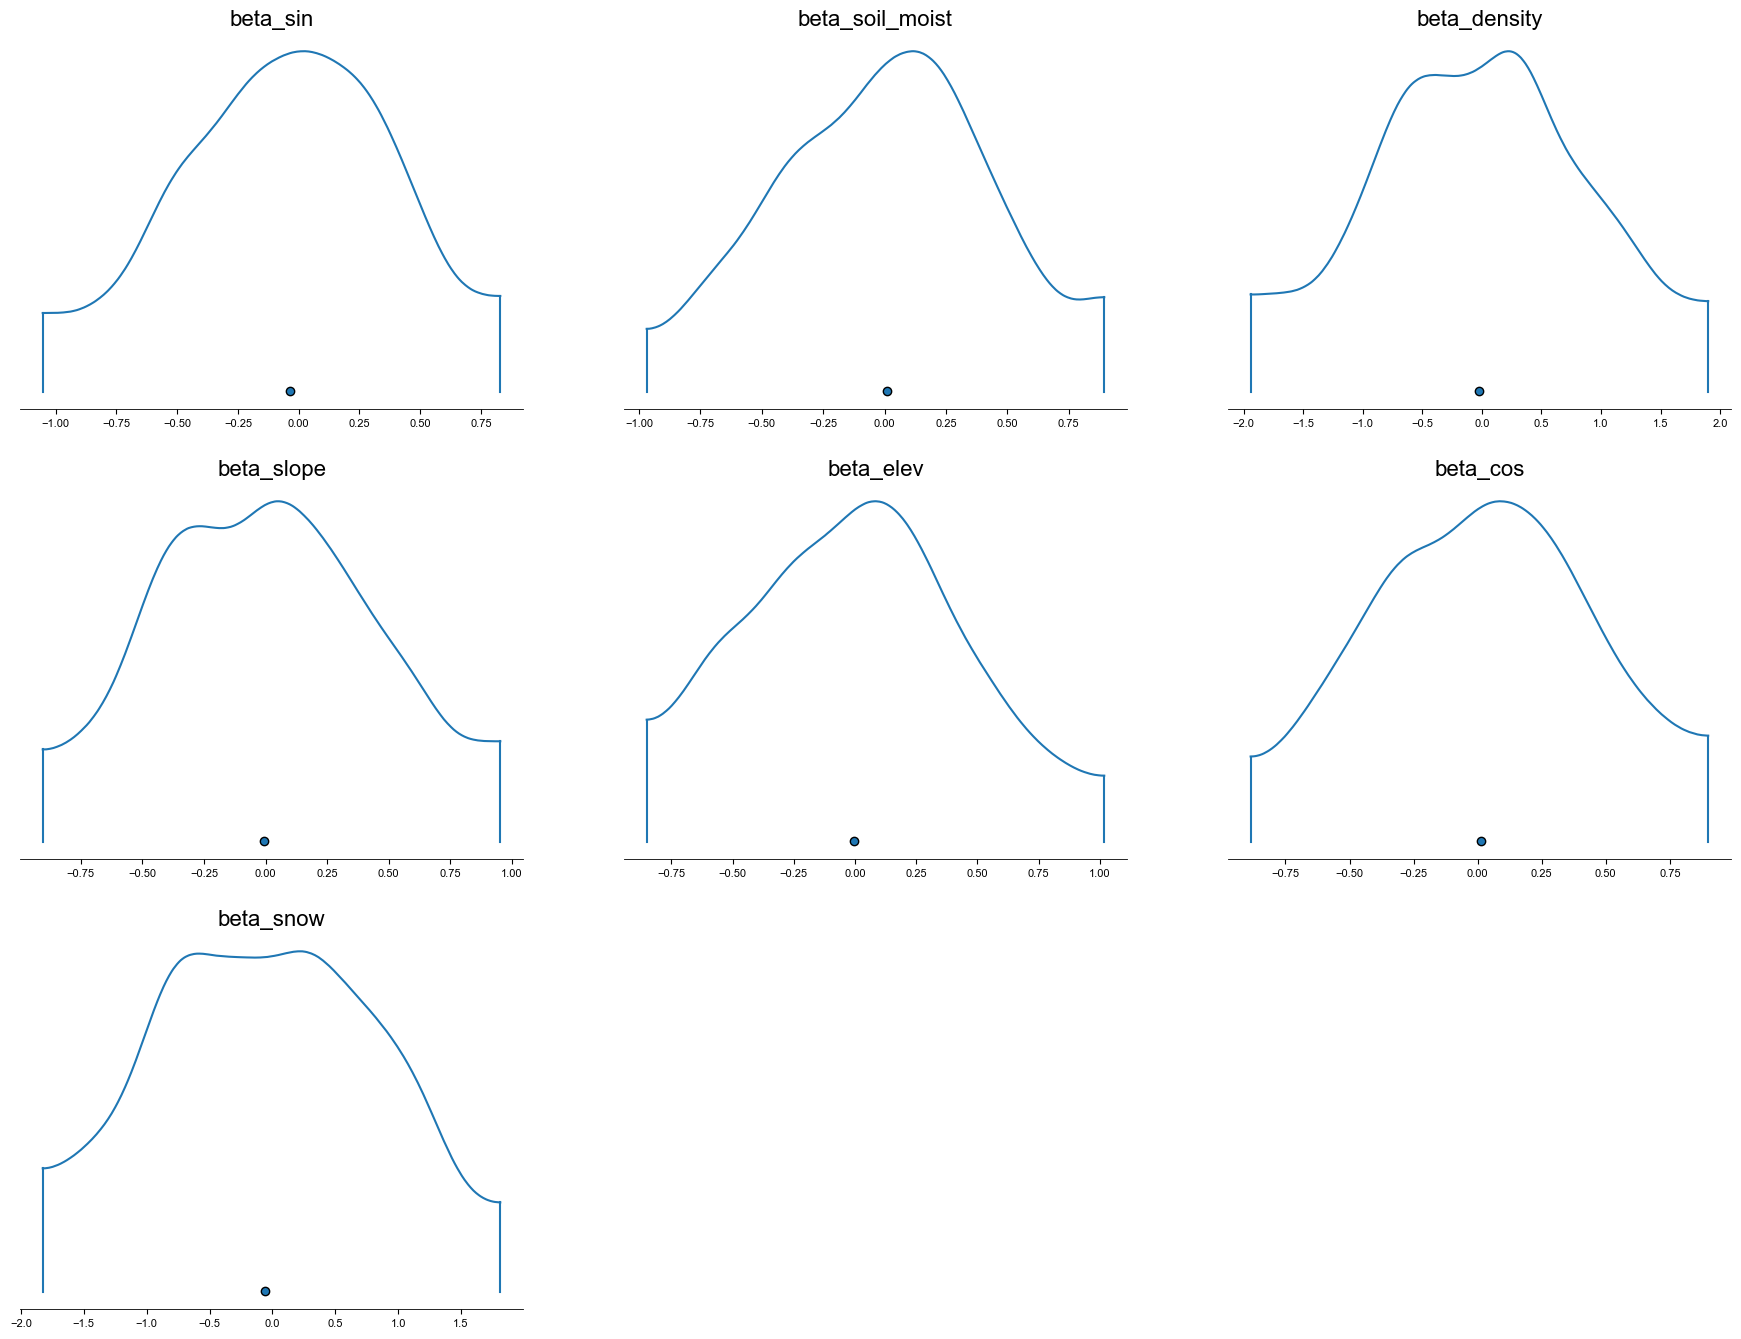

In [170]:
plot_all_prior_coefficients(model_depth_density_topography_moisture_prior)

In [171]:
prior_summary = summarize_all_prior_coefficients(model_depth_density_topography_moisture_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_sin,-0.03,0.50,-1.05,0.83,0.02,0.01,907.31,843.64,NaN
alpha,-7.09,1.48,-10.24,-4.56,0.05,0.03,976.43,780.49,NaN
beta_soil_moist,0.01,0.50,-0.97,0.90,0.01,0.01,1142.58,955.61,NaN
beta_density,-0.03,1.03,-1.94,1.90,0.03,0.02,940.11,940.72,NaN
beta_slope,-0.01,0.50,-0.91,0.96,0.02,0.01,952.79,809.92,NaN
beta_elev,-0.00,0.50,-0.85,1.02,0.01,0.01,1137.97,1025.93,NaN
sigma,3.23,2.40,0.00,7.36,0.08,0.07,951.56,983.44,NaN
beta_cos,0.01,0.48,-0.89,0.90,0.02,0.01,915.33,842.26,NaN
beta_snow,-0.06,1.00,-1.83,1.82,0.03,0.02,962.06,826.99,NaN


In [172]:
summary = summarize_all_posterior_coefficients(model_depth_density_topography_moisture_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,0.52,0.25,0.04,0.98,0.00,0.00,8749.74,5455.07,1.0
beta_density,0.11,0.78,-1.32,1.61,0.01,0.01,5848.95,6491.78,1.0
beta_slope,0.09,0.09,-0.07,0.27,0.00,0.00,6764.64,4855.01,1.0
beta_elev,-0.11,0.26,-0.60,0.36,0.00,0.00,5713.06,6343.17,1.0
beta_sin,-0.14,0.42,-0.92,0.68,0.00,0.00,8608.09,7813.62,1.0
beta_cos,0.17,0.40,-0.57,0.92,0.00,0.00,8667.35,8272.88,1.0
beta_soil_moist,0.18,0.25,-0.32,0.64,0.00,0.00,9183.40,7028.21,1.0
alpha,-6.90,1.44,-9.52,-4.12,0.02,0.02,6380.03,4481.56,1.0
sigma,1.41,0.61,0.70,2.40,0.01,0.02,4013.63,4248.69,1.0


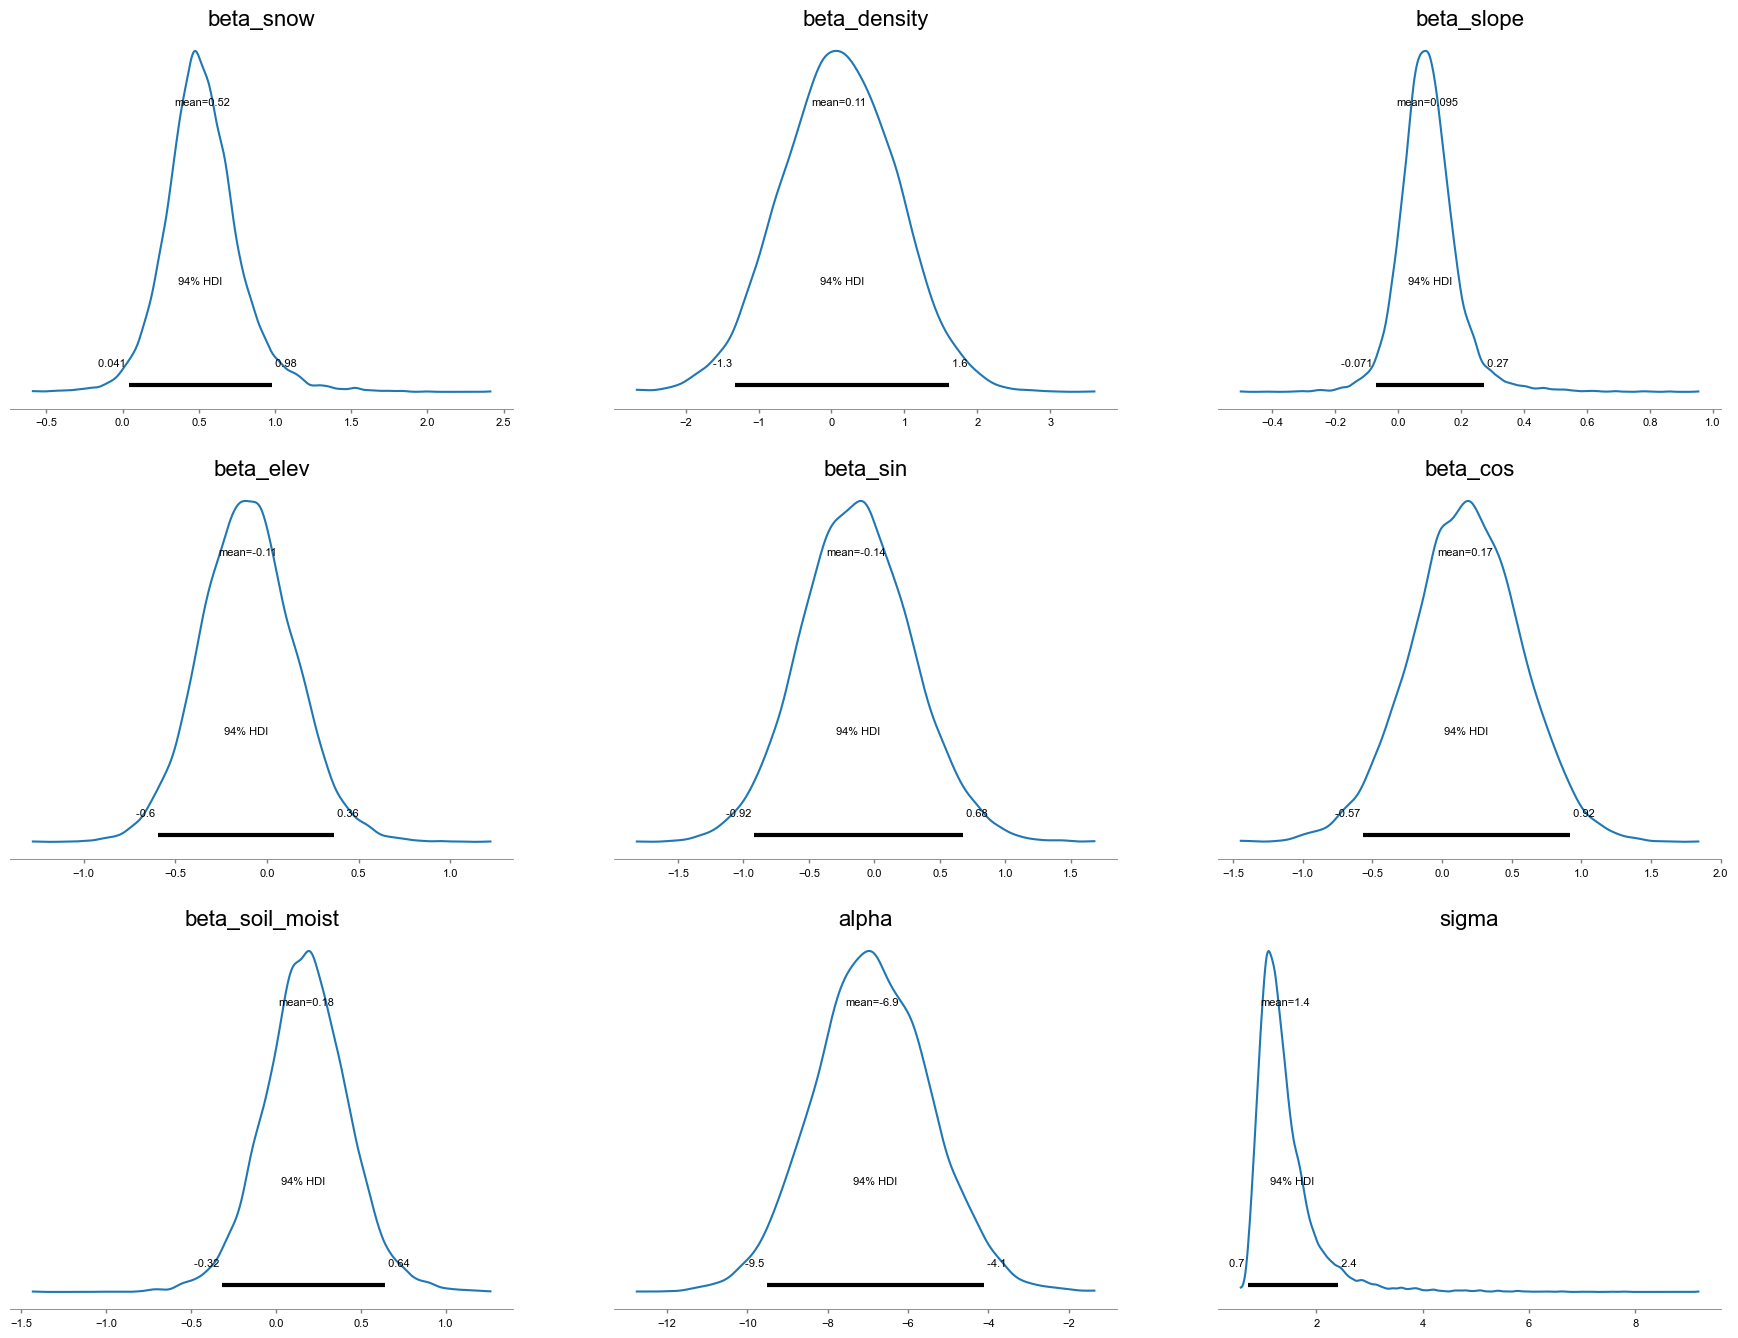

In [173]:
plot_all_posterior_coefficients(model_depth_density_topography_moisture_idata)

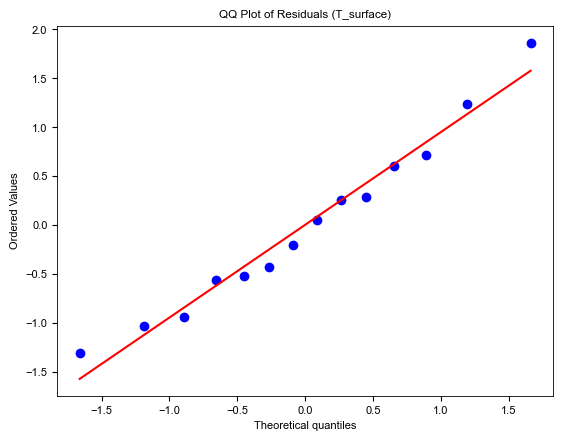

In [174]:
residuals = plot_residual_qq(
    model_depth_density_topography_moisture_idata,
    T_surface,
    var_name="T_surface"
)

In [175]:
r2_table = compute_bayesian_r2(
    model_depth_density_topography_moisture_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.541458,0.099506


In [176]:
loo_depth_density_topography_moisture = compute_loo(model_depth_density_topography_moisture_idata)
print(loo_depth_density_topography_moisture)

Computed from 12000 posterior samples and 14 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -25.60     2.18
p_loo        5.28        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       11   78.6%
   (0.70, 1]   (bad)         3   21.4%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

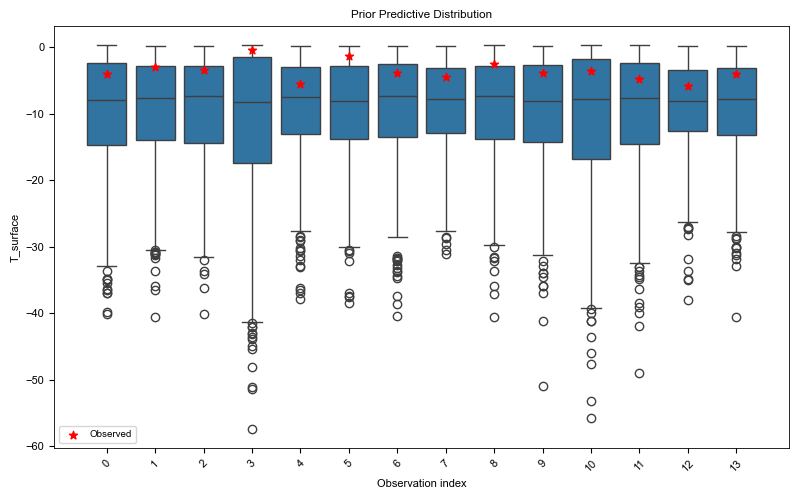

In [177]:
plot_prior_predictions(model_depth_density_topography_moisture_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

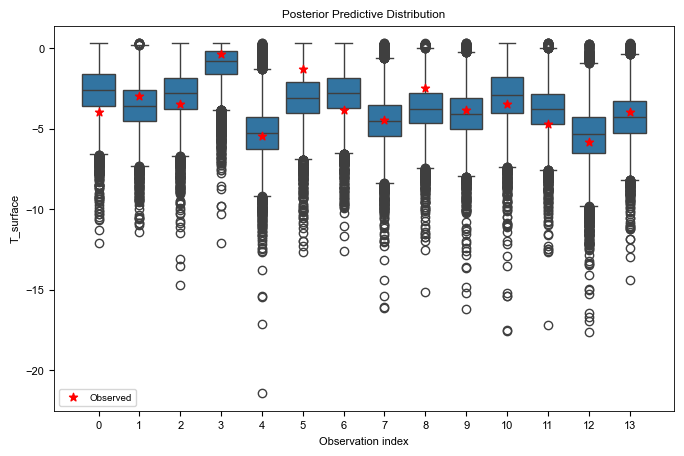

In [178]:
plot_predictions(model_depth_density_topography_moisture_idata)

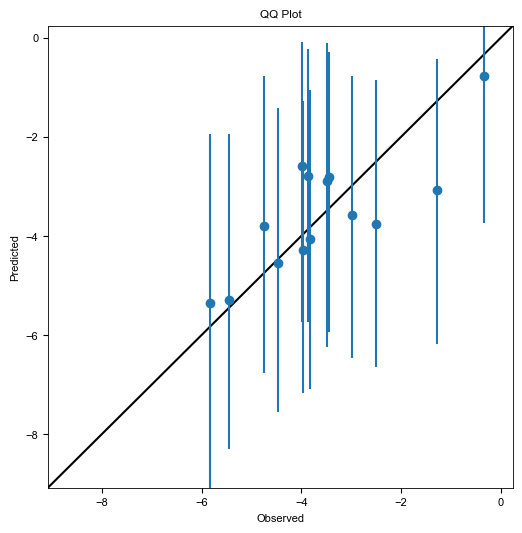

In [179]:
qqplot(model_depth_density_topography_moisture_idata)

# End

In [180]:
models = {
    "depth": model_depth_idata,
    "density": model_density_idata,
    "depth_density": model_depth_density_idata,
    "depth_topography": model_depth_topography_idata,
    "density_topography": model_density_topography_idata,
    "depth_density_topography": model_depth_density_topography_idata,
    "topography": model_topography_idata,
    "depth_density_topography_moisture":model_depth_density_topography_moisture_idata 
}



In [181]:
comparison_results = []

for name, idata in models.items():
    
    # R²
    r2 = compute_bayesian_r2(idata, T_surface)
    r2_mean = float(r2["R2_mean"].values[0])
    r2_sd   = float(r2["R2_sd"].values[0])
    
    # LOO
    loo = compute_loo(idata)
    
    comparison_results.append({
        "Model": name,
        "R2_mean": r2_mean,
        "R2_sd": r2_sd,
        "elpd_loo": loo.elpd_loo,
        "p_loo": loo.p_loo,
        "loo_se": loo.se
    })

comparison_table = pd.DataFrame(comparison_results)


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur0

In [182]:
comparison_table = comparison_table.sort_values(
    by="elpd_loo",
    ascending=False
)

comparison_table


,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se
0,depth,0.498235,0.105141,-23.066480,2.763438,2.773843
2,depth_density,0.491655,0.110355,-23.569156,3.114001,2.766445
3,depth_topography,0.541396,0.101108,-24.493244,4.340745,2.638633
5,depth_density_topography,0.537695,0.102137,-24.682828,4.514827,2.610725
7,depth_density_topography_moisture,0.541458,0.099506,-25.595976,5.277742,2.175837
1,density,0.355737,0.090430,-27.016472,2.171559,2.453006
4,density_topography,0.429329,0.092064,-27.687748,3.879390,1.857985
6,topography,0.426469,0.090642,-28.069561,3.656423,1.681593
